# Solana Anomaly Detection — Training Notebook

Loads the three monthly parquet files, builds the transaction-level feature matrix,
trains Isolation Forest + Feature-Attention Transformer AE, applies conformal prediction,


**No BigQuery queries.** All input is read from `/home/ubuntu/data/chunks/`.

## Experiment Suite

| # | Section | Goal |
|---|---------|------|
| 2 | Ablation | Measures each component's contribution vs baseline |
| 3 | Sensitivity | Measures stability of baseline across hyperparameter ranges |
| 4 | Contamination | Measures baseline detection rate on synthetic anomalies |
| 5 | Interpretability | Explains what the baseline flagged and why |

In [1]:
# 1. Clear out potential conflicts

# 2. Install the specific versions needed for your Solana pipeline


In [1]:
from google.colab import drive
!pip install -q optuna
!pip install kneed
import os, warnings, math
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import IsolationForest as _SklearnIF
from scipy.stats import spearmanr
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import joblib
import os, joblib, pickle, torch, numpy as np, polars as pl
import pickle
import shutil
import pyarrow as pa
import os, joblib, numpy as np
import warnings
import time
from sklearn.ensemble import IsolationForest
from kneed import KneeLocator
%matplotlib inline
import gc
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import copy
import optuna
from optuna.storages import RDBStorage
!pip install ninja
!pip install torchsort --no-build-isolation
!pip install torchcp
!pip install -q torchcp
import scipy.stats as stats
import os, numpy as np
import matplotlib.gridspec as gridspec
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm       import OneClassSVM
from statsmodels.stats.contingency_tables import mcnemar
import torch, gc, os, pickle
from joblib import Parallel, delayed
import torch, joblib
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.stats import entropy as scipy_entropy
import os, matplotlib.pyplot as plt, seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torchsort: filename=torchsort-0.1.10-cp312-cp312-linux_x86_64.whl size=3538375 sha256=70139334ae60ff46f43728ebcd929e6ebd551f56614b18a7c79e604a1c8a82ff
  Stored in directory: /root/.cache/pip/wheels/a8/20/ad/f2438a4a80e8b256e647cbba91f53559a9e8595b0a85988029
Successfully built torchsort
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.2/273.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.8 MB/s eta 0:00:00


In [2]:
# Global Checkpoint Configuration
CKPT = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/'
import os
os.makedirs(CKPT, exist_ok=True)


In [3]:
# 3. Re-run the mount command
from google.colab import drive

# Ensure the mount point is empty before mounting
!rm -rf /content/drive/*
!rmdir /content/drive || true  # Remove the directory if it's empty, ignore error if not
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
!ls drive/MyDrive/'Colab Notebooks'/vastaiFinal/checkpoints

chollet_capacity_regularised_df.pkl  scaler.pkl        transactions_norm.lance
iforest.pkl			     test_wallets.pkl  X_tx_norm.npy


In [4]:
# On plain PyTorch image: pip install --extra-index-url=https://pypi.nvidia.com cuml-cu12==24.10.*
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore')
matplotlib.use('Agg')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
torch.backends.cuda.enable_flash_sdp(False)         # incompatible with CUDA 13.0
torch.backends.cuda.enable_mem_efficient_sdp(False)  # incompatible with CUDA 13.0

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)


## Reload from checkpoints with Strict Error Handling (Global Scope)


## Scalers + features


## Scores


## Wallet-level outputs


## Split identifiers


## Model: Isolation Forest


## Model: Transformer AE


## Optional: results


In [10]:
import os
import joblib
import numpy as np
import polars as pl
import pickle
import torch

print(f'Scanning {CKPT} for checkpoints...')
files = os.listdir(CKPT)

# Group by extension to control load order (.npy must be before .pt)
file_groups = {'npy': [], 'pkl': [], 'parquet': [], 'pt': []}
for f in files:
    ext = f.split('.')[-1]
    if ext in file_groups:
        file_groups[ext].append(f)

# 1. Load .npy arrays first
print('\n--- Loading .npy files ---')
for f in file_groups['npy']:
    var_name = f.replace('.npy', '')
    path = os.path.join(CKPT, f)
    globals()[var_name] = np.load(path)
    print(f'Loaded {var_name}: {globals()[var_name].shape}')

# 2. Load .pkl files
print('\n--- Loading .pkl files ---')
for f in file_groups['pkl']:
    var_name = f.replace('.pkl', '')
    path = os.path.join(CKPT, f)
    try:
        # Try joblib first (for models/scalers)
        globals()[var_name] = joblib.load(path)
    except:
        # Fallback to standard pickle (for lists/scalars)
        with open(path, 'rb') as _f:
            globals()[var_name] = pickle.load(_f)
    print(f'Loaded {var_name}')

# 3. Load .parquet files
print('\n--- Loading .parquet files ---')
for f in file_groups['parquet']:
    var_name = f.replace('.parquet', '')
    path = os.path.join(CKPT, f)
    globals()[var_name] = pl.read_parquet(path).to_pandas()
    print(f'Loaded {var_name}: {globals()[var_name].shape}')

# 4. Load .pt files (PyTorch models)
print('\n--- Loading .pt files ---')
for f in file_groups['pt']:
    var_name = f.replace('.pt', '')
    path = os.path.join(CKPT, f)
    try:
        _ckpt = torch.load(path, map_location='cpu')
        if 'cfg' in _ckpt and 'state_dict' in _ckpt:
            cfg = _ckpt['cfg']
            # Attempt to instantiate model if X_tx_norm is loaded
            if 'X_tx_norm' in globals():
                device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
                # Filter out training-specific keys
                model_kwargs = {k: v for k, v in cfg.items() if k not in ['epochs', 'lr', 'weight_decay', 'batch_size']}
                model = WalletTransformerAE(
                    n_features=X_tx_norm.shape[1],
                    **model_kwargs
                )
                model.load_state_dict(_ckpt['state_dict'])
                globals()[var_name] = model.to(device).eval()
                print(f'Loaded model {var_name} onto {device}')
            else:
                print(f'Skipped instantiating {var_name}: X_tx_norm not found.')
        else:
             globals()[var_name] = _ckpt
             print(f'Loaded raw PyTorch object: {var_name}')
    except Exception as e:
        print(f'Failed to load {f}: {e}')

print('\n=== Dynamic Reload Complete ===')

Scanning /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/ for checkpoints...

--- Loading .npy files ---
Loaded X_tx_norm: (2905990, 25)

--- Loading .pkl files ---
Loaded scaler
Loaded iforest
Loaded chollet_capacity_regularised_df
Loaded test_wallets
Loaded if_model_optimised

--- Loading .parquet files ---

--- Loading .pt files ---
Loaded model ae_model_optimised onto cuda

=== Dynamic Reload Complete ===


In [7]:
try:
    scaler     = joblib.load(CKPT + 'scaler.pkl')
    X_tx_norm  = np.load(CKPT + 'X_tx_norm.npy')
    print(f'X_tx_norm: {X_tx_norm.shape}')
except Exception as e:
    raise FileNotFoundError(f"CRITICAL: Failed to load scaler or feature matrix from {CKPT}. Error: {e}")

try:
    if_tx_score     = np.load(CKPT + 'if_tx_score.npy')
    tr_tx_score     = np.load(CKPT + 'tr_tx_score.npy')
    per_feat_errors = np.load(CKPT + 'per_feat_errors.npy')
    combined_tx     = np.load(CKPT + 'combined_tx_score.npy')
    cal_scores      = np.load(CKPT + 'cal_scores.npy')
    print(f'Scores loaded. cal_scores: {len(cal_scores)}')
except Exception as e:
    raise FileNotFoundError(f"CRITICAL: Failed to load score arrays. Error: {e}")

try:
    wallet_scores = pl.read_parquet(CKPT + 'wallet_scores_final.parquet').to_pandas()
    df_flat       = pl.read_parquet(CKPT + 'transactions_scored.parquet').to_pandas()
    print(f'wallet_scores: {wallet_scores.shape}, df_flat: {df_flat.shape}')
except Exception as e:
    raise FileNotFoundError(f"CRITICAL: Scored parquet files missing. Error: {e}")

try:
    with open(CKPT + 'test_wallets.pkl', 'rb') as _f:
        test_wallets = pickle.load(_f)
    with open(CKPT + 'alpha.pkl', 'rb') as _f:
        ALPHA = pickle.load(_f)
    print(f'test_wallets: {len(test_wallets)}, ALPHA: {ALPHA}')
except Exception as e:
    raise FileNotFoundError(f"CRITICAL: Split identifiers missing. Error: {e}")

try:
    iforest  = joblib.load(CKPT + 'iforest.pkl')
    print('iforest loaded')
except Exception as e:
    raise RuntimeError(f"CRITICAL: Isolation Forest loading failed. Error: {e}")

try:
    _ae_ckpt = torch.load(CKPT + 'ae_model.pt', map_location='cpu')
    TR_CFG   = _ae_ckpt['cfg']
    device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tr_model = WalletTransformerAE(n_features=X_tx_norm.shape[1], **{k: v for k, v in TR_CFG.items() if k != 'epochs'})
    tr_model.load_state_dict(_ae_ckpt['state_dict'])
    tr_model = tr_model.to(device).eval()
    print(f'tr_model loaded on {device}')
except Exception as e:
    raise RuntimeError(f"CRITICAL: Transformer AE loading failed. Error: {e}")

struct_perm_df, struct_perm_summary, decay_df = None, None, None

if os.path.exists(CKPT + 'struct_perm_df.parquet'):
    struct_perm_df      = pl.read_parquet(CKPT + 'struct_perm_df.parquet').to_pandas()
    struct_perm_summary = pl.read_parquet(CKPT + 'struct_perm_summary.parquet').to_pandas()
    print(f'struct_perm_df: {struct_perm_df.shape}')

if os.path.exists(CKPT + 'decay_df.parquet'):
    decay_df = pl.read_parquet(CKPT + 'decay_df.parquet').to_pandas()
    print(f'decay_df: {decay_df.shape}')

print('\n=== Reload complete ===')

X_tx_norm: (2905990, 25)


FileNotFoundError: CRITICAL: Failed to load score arrays. Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_tx_score.npy'

## GPU / AMP


## cuML FIL availability


## IsolationForest wrapper


In [18]:
if torch.cuda.is_available():
    device  = torch.device('cuda')
    props   = torch.cuda.get_device_properties(0)
    USE_AMP = props.major >= 8
    print(f'Device : {props.name} | {props.total_memory // 1024**3} GB VRAM')
    print(f'AMP    : {"BFloat16" if USE_AMP else "Disabled"}')
else:
    device, USE_AMP = torch.device('cpu'), False
    print('Device : CPU')

PRECISION = torch.bfloat16 if USE_AMP else torch.float32
np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

try:
    from cuml.fil import ForestInference
    _HAS_FIL = True
    print('cuML FIL : ENABLED (GPU inference via ForestInference)')
except ImportError:
    _HAS_FIL = False
    print('cuML FIL : not found — sklearn CPU scoring will be used')

# Training  : always sklearn on CPU (fast — max_samples is small per tree).
# Inference : ForestInference.load_from_sklearn transfers the fitted forest to
#             GPU via cuml/treelite; predict() scores 2.9M rows in ~1–2 s.
#             Falls back to sklearn.decision_function when FIL is unavailable.
#
# Score convention: decision_function returns sklearn-equivalent scores
#   (higher = more normal). Callers negate to get anomaly scores.
#
# free_gpu() releases the FIL handle between Optuna trials to reclaim VRAM.

class IsolationForest:
    def __init__(self, n_estimators=100, max_samples=256, contamination=0.005,
                 random_state=42, n_jobs=-1, bootstrap=False, max_features=1.0):
        _cont = 0.005 if contamination == 'auto' else float(contamination)
        self._model = _SklearnIF(
            n_estimators=n_estimators, max_samples=max_samples,
            contamination=_cont, random_state=random_state,
            n_jobs=n_jobs, bootstrap=bootstrap, max_features=max_features)
        self._fil = None

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self._model.fit(X)
        if _HAS_FIL:
            try:
                self._fil = ForestInference.load_from_sklearn(
                    self._model)
            except Exception as _e:
                print(f'  FIL load failed ({_e}) — falling back to CPU scoring')
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=np.float32)
        if self._fil is not None:
            fil_scores = np.asarray(self._fil.predict(X)).ravel()
            # FIX: Negate the FIL score to match sklearn's score_samples behaviour
            return -fil_scores - self._model.offset_
        return self._model.decision_function(X)

    def free_gpu(self):
        self._fil = None
        torch.cuda.empty_cache()


    def __getstate__(self):
        # Remove the unpicklable FIL object before saving
        state = self.__dict__.copy()
        state['_fil'] = None
        return state

    def __setstate__(self, state):
        # Restore state and try to reload FIL if available
        self.__dict__.update(state)
        if _HAS_FIL:
            try:
                self._fil = ForestInference.load_from_sklearn(self._model)
            except Exception:
                pass


Device : NVIDIA L4 | 22 GB VRAM
AMP    : BFloat16
cuML FIL : ENABLED (GPU inference via ForestInference)


In [19]:
CACHE = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/engineered_features_cache.parquet'
if not os.path.exists(CACHE):
    raise FileNotFoundError('engineered_features_cache.parquet not found')

df_flat = pl.read_parquet(CACHE)
print(f'Loaded: {df_flat.shape[0]:,} rows, {df_flat["wallet"].n_unique():,} wallets')


Loaded: 2,905,990 rows, 619,160 wallets


## Timestamp + sort


In [20]:
# block_timestamp is already Datetime[us, UTC] in the parquet — no conversion needed.
df_flat = df_flat.sort(['wallet', 'block_timestamp'])

# Per-tx time since wallet's previous transaction (0 for first tx)
df_flat = df_flat.with_columns(
    pl.col('block_timestamp')
    .diff()
    .over('wallet')
    .dt.total_seconds()
    .fill_null(0.0)
    .alias('delta_time')
)
print('Timestamps OK. delta_time computed.')


Timestamps OK. delta_time computed.


## EDA: Dataset characterisation


## Plots


In [21]:
print('=== Dataset Overview ===')
print(f'Date range : {df_flat["block_timestamp"].min()} -> {df_flat["block_timestamp"].max()}')
print(f'Rows       : {df_flat.shape[0]:,}')
print(f'Wallets    : {df_flat["wallet"].n_unique():,}')

# Transactions per wallet
_tpw = df_flat.group_by('wallet').len().rename({'len': 'n_tx'})
print('\nTransactions per wallet:')
print(_tpw['n_tx'].to_pandas().describe(percentiles=[.25, .5, .75, .90, .99]).round(1))

# Add _month as 'YYYY-MM' string (also used in rolling-window cell)
df_flat = df_flat.with_columns(
    pl.col('block_timestamp').dt.strftime('%Y-%m').alias('_month')
)

# Monthly breakdown
monthly_vol = (
    df_flat.group_by('_month')
    .agg([
        pl.len().alias('n_tx'),
        pl.col('wallet').n_unique().alias('n_wallets'),
    ])
    .sort('_month')
)

first_seen_month = (
    df_flat.group_by('wallet')
    .agg(pl.col('block_timestamp').min().dt.strftime('%Y-%m').alias('_month'))
    .group_by('_month')
    .len()
    .rename({'len': 'n_new_wallets'})
)

monthly_vol = (
    monthly_vol
    .join(first_seen_month, on='_month', how='left')
    .with_columns(pl.col('n_new_wallets').fill_null(0))
    .with_columns([
        (pl.col('n_tx') / pl.col('n_wallets').clip(lower_bound=1))
            .cast(pl.Float64).alias('tx_per_wallet'),
        (100.0 * pl.col('n_new_wallets') / pl.col('n_wallets').clip(lower_bound=1))
            .cast(pl.Float64).alias('pct_new_wallets'),
    ])
)

print('\nMonthly breakdown (expanded):')
print(monthly_vol.to_pandas().to_string(index=False))

single_tx = (_tpw['n_tx'] == 1).sum()
multi_tx  = (_tpw['n_tx'] > 1).sum()
print(f'\nSingle-tx wallets: {single_tx:,}  ({single_tx / len(_tpw) * 100:.1f}%)')
print(f'Multi-tx wallets : {multi_tx:,}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# A) Wallet activity concentration
_tpw_np = _tpw['n_tx'].to_numpy()
sns.histplot(_tpw_np, bins=60, log_scale=(True, False), color='#4C78A8', ax=axes[0])
axes[0].set_title('Transactions per Wallet (log-x)')
axes[0].set_xlabel('Transactions per wallet')
axes[0].set_ylabel('Wallet count')

# B) Monthly turnover and wallet freshness
_month_plot = monthly_vol.to_pandas()
sns.barplot(data=_month_plot, x='_month', y='tx_per_wallet', color='#F58518', ax=axes[1])
axes[1].set_title('Tx per Active Wallet by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Transactions per active wallet')
ax1b = axes[1].twinx()
sns.lineplot(data=_month_plot, x='_month', y='pct_new_wallets',
             marker='o', color='#54A24B', linewidth=1.8, ax=ax1b)
ax1b.set_ylabel('New-wallet share (%)')
ax1b.grid(False)

# C) Key feature distributions
# (instigator_sol_delta + instigator_net_token_profit replace the former
#  balance_churn_rate / total_vol which are not in this dataset)
key_feats = ['fee_sol', 'max_sol_change', 'instigator_sol_delta', 'instigator_net_token_profit']
_dist_parts = []
for feat in key_feats:
    vals = df_flat[feat].cast(pl.Float64).to_numpy()
    lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    _dist_parts.append(pd.DataFrame({'feature': feat, 'value': np.clip(vals, lo, hi)}))

dist_df = pd.concat(_dist_parts, ignore_index=True)
sns.boxenplot(data=dist_df, x='feature', y='value', ax=axes[2], color='#72B7B2')
axes[2].set_title('Key Feature Spread (clipped [1%, 99%])')
axes[2].set_xlabel('Feature')
axes[2].set_ylabel('Value')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: eda_overview.png')

=== Dataset Overview ===
Date range : 2024-09-01 00:00:02+00:00 -> 2025-01-31 23:40:43+00:00
Rows       : 2,905,990
Wallets    : 619,160

Transactions per wallet:
count    619160.0
mean          4.7
std         367.6
min           1.0
25%           1.0
50%           1.0
75%           1.0
90%           1.0
99%          48.0
max      178862.0
Name: n_tx, dtype: float64

Monthly breakdown (expanded):
 _month   n_tx  n_wallets  n_new_wallets  tx_per_wallet  pct_new_wallets
2024-09 500791     122696         122696       4.081559       100.000000
2024-10 628683     154409         152071       4.071544        98.485840
2024-11 760275     176601         172775       4.305044        97.833534
2024-12 707659     131707         125870       5.372979        95.568193
2025-01 308582      50606          45748       6.097735        90.400348

Single-tx wallets: 579,823  (93.6%)
Multi-tx wallets : 39,337
Saved: eda_overview.png


## Feature columns


In [22]:
# Source parquet: 28 cols  →  30 in df_flat (+ delta_time, _month)
# cs.numeric() picks up all 25 usable features automatically:
#   21 × Float32  original transaction metrics
#    3 × Int8     has_fiat_profit / has_token_profit / has_sol_profit
#    1 × Float64  delta_time  (inter-tx interval, added in cell 5)
# Excluded (5): signature, block_timestamp, tx_date, wallet, _month

tx_feature_cols = df_flat.select(cs.numeric()).columns  # list[str], length 25

# Cast everything to Float32, replace inf / nan → 0
df_flat = df_flat.with_columns([
    pl.col(col).cast(pl.Float32).fill_nan(0.0).fill_null(0.0)
    for col in tx_feature_cols
])

X_tx = df_flat.select(tx_feature_cols).to_numpy().astype(np.float32)  # (N_tx, 25)
n_inf = np.isinf(X_tx).sum()
n_nan = np.isnan(X_tx).sum()
print(f'Features      : {tx_feature_cols}')
print(f'X_tx shape    : {X_tx.shape}  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "Unexpected inf/nan in feature matrix!"

Features      : ['fee_sol', 'compute_units_consumed', 'success_flag', 'involves_sysvar_flag', 'max_cpi_depth', 'inner_instruction_count', 'dex_hop_count', 'debt_hop_count', 'instigator_net_token_profit', 'instigator_sol_delta', 'instigator_fiat_delta', 'unique_nonsigner_account_count', 'log_count', 'num_accounts', 'num_balance_changes', 'max_sol_change', 'mint_diversity', 'unique_program_count', 'hop_density', 'avg_depth_per_protocol', 'unknown_program_count', 'has_fiat_profit', 'has_token_profit', 'has_sol_profit', 'delta_time']
X_tx shape    : (2905990, 25)  |  inf=0  nan=0


## Rolling Window Split Logic


In [23]:
# _month is a 'YYYY-MM' string column added in the EDA cell.
all_months = sorted(df_flat['_month'].unique().to_list())
print(f'Available months in dataset: {all_months}')

if len(all_months) < 3:
    raise ValueError(f"Need at least 3 months for a rolling window, found {len(all_months)}: {all_months}")

rolling_windows = []
for i in range(len(all_months) - 2):
    rolling_windows.append((all_months[i], all_months[i+1], all_months[i+2]))

print(f'Defined {len(rolling_windows)} rolling windows:')
for i, w in enumerate(rolling_windows):
    print(f'  W{{i+1}}: Train={{w[0]}}, Val={{w[1]}}, Test={{w[2]}}')

def get_window_masks(df, train_m, val_m, test_m):
    train_w = set(df.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
    val_w   = set(df.filter(pl.col('_month') == val_m  )['wallet'].unique().to_list())
    test_w  = set(df.filter(pl.col('_month') == test_m )['wallet'].unique().to_list())

    # Ensure no overlap for strict evaluation
    val_w  = val_w  - train_w
    test_w = test_w - train_w - val_w

    m_train = (df['wallet'].is_in(list(train_w)) & (df['_month'] == train_m)).to_numpy()
    m_val   = (df['wallet'].is_in(list(val_w))   & (df['_month'] == val_m  )).to_numpy()
    m_test  = (df['wallet'].is_in(list(test_w))  & (df['_month'] == test_m )).to_numpy()

    return (m_train, m_val, m_test,
            np.array(list(train_w)), np.array(list(val_w)), np.array(list(test_w)))

# Initialize masks for the first window
train_m, val_m, test_m = rolling_windows[0]
train_mask_tx, val_mask_tx, test_mask_tx, train_wallets, val_wallets, test_wallets = \
    get_window_masks(df_flat, train_m, val_m, test_m)

# Save split identifiers
with open(CKPT + 'test_wallets.pkl', 'wb') as f:
    pickle.dump(test_wallets, f)
print('Saved: test_wallets.pkl')


Available months in dataset: ['2024-09', '2024-10', '2024-11', '2024-12', '2025-01']
Defined 3 rolling windows:
  W{i+1}: Train={w[0]}, Val={w[1]}, Test={w[2]}
  W{i+1}: Train={w[0]}, Val={w[1]}, Test={w[2]}
  W{i+1}: Train={w[0]}, Val={w[1]}, Test={w[2]}
Saved: test_wallets.pkl


## Normalisation (fit on train only)


In [24]:
#  QuantileTransformer.
# This forces extreme long-tailed economic data and bursty counts into a
# smooth uniform [0, 1] distribution, completely avoiding gradient explosion
# while preserving the rank-extremity of outliers without blind clipping.


scaler = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaler.fit(X_tx[train_mask_tx])
X_tx_norm = scaler.transform(X_tx).astype(np.float32)

n_inf = np.isinf(X_tx_norm).sum()
n_nan = np.isnan(X_tx_norm).sum()
print(f'Normalised  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "inf/nan after normalisation — check raw features!"

print('')
print(pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols)
      .describe().loc[['mean','50%','std']].round(3))

Normalised  |  inf=0  nan=0

      fee_sol  compute_units_consumed  success_flag  involves_sysvar_flag  \
mean    0.495                   0.501           0.0                 0.025   
50%     0.511                   0.505           0.0                 0.000   
std     0.303                   0.286           0.0                 0.157   

      max_cpi_depth  inner_instruction_count  dex_hop_count  debt_hop_count  \
mean          0.497                    0.501          0.494           0.000   
50%           0.349                    0.394          0.486           0.000   
std           0.242                    0.281          0.216           0.011   

      instigator_net_token_profit  instigator_sol_delta  ...  max_sol_change  \
mean                        0.493                 0.502  ...           0.499   
50%                         0.498                 0.503  ...           0.519   
std                         0.298                 0.287  ...           0.289   

      mint_diversity  un

In [25]:
# Build wallet index for sequences
if isinstance(df_flat, pd.DataFrame):
    df_subset = pl.from_pandas(df_flat[['wallet']])
else:
    df_subset = df_flat.select('wallet')

idx_df = (
    df_subset
    .with_row_index('_row')
    .group_by('wallet', maintain_order=True)
    .agg([pl.col('_row').min().alias('start_row'), pl.len().alias('seq_len')])
)

WALLET_INDEX = {
    row[0]: (int(row[1]), int(row[2]))
    for row in idx_df.iter_rows()
}
print(f'Wallet index  : {len(WALLET_INDEX):,} wallets')


Wallet index  : 619,160 wallets


In [26]:
import joblib
import os

xtx_path = os.path.join(CKPT, 'X_tx.pkl')
joblib.dump(X_tx, xtx_path)
print(f'Saved X_tx to {xtx_path}')

Saved X_tx to /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/X_tx.pkl


## Checkpoint: save scaler + normalised features


In [16]:
joblib.dump(scaler, CKPT + 'scaler.pkl')
print('Saved: scaler.pkl')

np.save(CKPT + 'X_tx_norm.npy', X_tx_norm)
print('Saved: X_tx_norm.npy')

Saved: scaler.pkl
Saved: X_tx_norm.npy


## Feature collinearity & VIF analysis


In [17]:
try: from statsmodels.stats.outliers_influence import variance_inflation_factor; _HAS_SM = True
except ImportError: _HAS_SM = False; print('statsmodels not found — skipping VIF')

_corr = pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols).corr()

_hc = [{'feat_a': tx_feature_cols[i], 'feat_b': tx_feature_cols[j], 'pearson_r': round(float(_corr.iloc[i, j]), 3)} for i in range(len(tx_feature_cols)) for j in range(i+1, len(tx_feature_cols)) if abs(_corr.iloc[i, j]) > 0.80]
hc_df = pd.DataFrame(_hc).sort_values('pearson_r', ascending=False, key=abs).reset_index(drop=True) if _hc else pd.DataFrame()
print('Highly correlated pairs (|r| > 0.80):\n', hc_df.to_string(index=False) if len(hc_df) else '  None found.')

if _HAS_SM:
    _Xv = X_tx_norm[train_mask_tx][np.random.default_rng(42).choice(train_mask_tx.sum(), size=min(8000, train_mask_tx.sum()), replace=False)]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        vif_df = pd.DataFrame({'feature': tx_feature_cols, 'VIF': [variance_inflation_factor(_Xv, k) for k in range(_Xv.shape[1])]}).sort_values('VIF', ascending=False)
    print('\nVariance Inflation Factors (top 15):\n', vif_df.head(15).to_string(index=False))
    print(f'Features with VIF > 10: {vif_df[vif_df.VIF > 10]["feature"].tolist()}')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature Pearson Correlation Matrix (train split)', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7); ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout(); plt.savefig('feature_correlation_heatmap.png', dpi=120, bbox_inches='tight'); plt.show(); plt.close()
print('Saved: feature_correlation_heatmap.png')

Highly correlated pairs (|r| > 0.80):
                         feat_a                feat_b  pearson_r
                  num_accounts   num_balance_changes      1.000
       inner_instruction_count             log_count      0.959
         instigator_fiat_delta       has_fiat_profit      0.941
unique_nonsigner_account_count          num_accounts      0.935
unique_nonsigner_account_count   num_balance_changes      0.935
          unique_program_count unknown_program_count      0.872

Variance Inflation Factors (top 15):
                        feature        VIF
           num_balance_changes        inf
                  num_accounts        inf
          unique_program_count 179.203552
                 max_cpi_depth 150.006851
unique_nonsigner_account_count 128.240692
         unknown_program_count 113.672935
         instigator_fiat_delta  75.528137
        avg_depth_per_protocol  60.590534
       inner_instruction_count  59.148224
                     log_count  55.667240
            

## IF baseline diagnostics (pre-Optuna)


In [30]:
%matplotlib inline

# Define search space/baselines
_if_diag_cfgs = [
    dict(profile='fast', n_estimators=100, max_samples=256, contamination='auto'),
    dict(profile='standard', n_estimators=300, max_samples=256, contamination='auto'),
    dict(profile='deep', n_estimators=500, max_samples=1024, contamination='auto'),
    dict(profile='shallow_wide', n_estimators=100, max_samples=1024, contamination='auto'),
    dict(profile='deep_narrow', n_estimators=500, max_samples=128, contamination='auto'),
]

def _run_if_diag(c):
    t0 = time.time()

    # 0. Initialize and Fit the model
    # Note: X_tx and train_mask_tx must be available in your global scope
    _if_model = IsolationForest(
        n_estimators=c['n_estimators'],
        max_samples=c['max_samples'],
        contamination=c['contamination'],
        random_state=42,
        n_jobs=-1 # Speed up execution
    )
    _if_model.fit(X_tx[train_mask_tx])

    # 1. Get raw scores (negated decision function)
    # Higher = more anomalous
    raw_scores = -_if_model.decision_function(X_tx[train_mask_tx])

    # Focus on the Upper Half (Top 50%) to find the structural break
    median_score = np.median(raw_scores)
    upper_half_scores = raw_scores[raw_scores > median_score]
    sorted_scores = np.sort(upper_half_scores)
    x = np.arange(len(sorted_scores))

    # 2. Synchronized Knee Calculation
    kneedle = KneeLocator(
        x,
        sorted_scores,
        S=1.0,
        curve='convex',
        direction='increasing',
        interp_method='polynomial'
    )

    # 3. Extract Metrics
    if kneedle.knee is None:
        optimal_th, candidate_rate, knee_sharpness = np.nan, 0.0, 0.0
    else:
        optimal_idx = kneedle.knee
        optimal_th = sorted_scores[optimal_idx]
        candidate_rate = (raw_scores >= optimal_th).mean()

        # 'Sharpness' measures the gap in the extreme tail (99.5th percentile)
        p995 = np.percentile(raw_scores, 99.5)
        knee_sharpness = p995 - optimal_th

    # Cleanup memory
    del _if_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'profile': c['profile'],
        'fit_time_s': round(time.time() - t0, 2),
        'candidate_rate': float(candidate_rate),
        'knee_sharpness': float(knee_sharpness),
        'optimal_threshold': float(optimal_th),
        'n_estimators': c['n_estimators'],
        'max_samples': c['max_samples']
    }

# Run the evaluation
print("Starting Isolation Forest structural diagnostics...")
if_capacity_df = pd.DataFrame([_run_if_diag(c) for c in _if_diag_cfgs])

# Rank the models based on structural clarity (Targeting 2% - 20% flag rate)
valid_models = if_capacity_df[
    (if_capacity_df['candidate_rate'] >= 0.02) &
    (if_capacity_df['candidate_rate'] <= 0.20)
]

if not valid_models.empty:
    best_profile = valid_models.sort_values('knee_sharpness', ascending=False).iloc[0]
else:
    best_profile = if_capacity_df.sort_values('knee_sharpness', ascending=False).iloc[0]
    print("\nWarning: No profiles hit the 2%-20% candidate rate target.")

print('\nIF Capacity diagnostics:\n', if_capacity_df.to_string(index=False))
print(f"\nRecommended IF center for Optuna: {best_profile['profile']} (Rate: {best_profile['candidate_rate']*100:.2f}%)")

Starting Isolation Forest structural diagnostics...

IF Capacity diagnostics:
      profile  fit_time_s  candidate_rate  knee_sharpness  optimal_threshold  n_estimators  max_samples
        fast        0.99        0.124781        0.124107          -0.124107           100          256
    standard        2.52        0.129883        0.124606          -0.124606           300          256
        deep        5.24        0.104243        0.130869          -0.130869           500         1024
shallow_wide        1.18        0.105968        0.135377          -0.135377           100         1024
 deep_narrow        3.74        0.140841        0.120280          -0.120280           500          128

Recommended IF center for Optuna: shallow_wide (Rate: 10.60%)


## Isolation Forest


In [19]:
IF_CFG = dict(n_estimators=100, max_samples=1024,
                  contamination='auto', random_state=42, n_jobs=-1)

print('Fitting Isolation Forest...')
iforest = IsolationForest(**IF_CFG).fit(X_tx[train_mask_tx])

# Extract raw continuous scores
if_raw = -iforest.decision_function(X_tx)

"""
# CDF normalisation (Kriegel et al. 2011)
if_train_sort = np.sort(if_raw[train_mask_tx])
if_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)
print(f'IF CDF Range: [{if_tx_score.min():.4f}, {if_tx_score.max():.4f}]')
"""
# Save model
joblib.dump(iforest, CKPT + 'iforest.pkl')
print('Saved: iforest.pkl')


Fitting Isolation Forest...
Saved: iforest.pkl


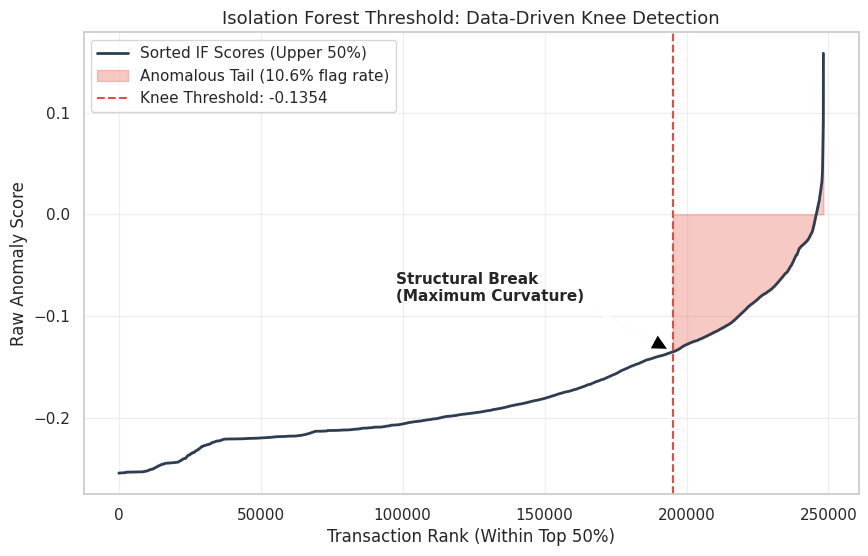

Verified Statistics:
Optimal Threshold: -0.1354
Candidate Flag Rate: 10.60%


In [32]:
%matplotlib inline

#1. Prepare scores from the GLOBAL if_raw
# Ensure if_raw and train_mask_tx are defined in previous cells
raw_train_scores = if_raw[train_mask_tx]
median_score = np.median(raw_train_scores)
upper_half_scores = raw_train_scores[raw_train_scores > median_score]
sorted_scores = np.sort(upper_half_scores)
x = np.arange(len(sorted_scores))

# 2. Synchronized Knee Calculation (Matches Diagnostics Loop exactly)
kneedle = KneeLocator(
    x,
    sorted_scores,
    S=1.0,
    curve='convex',
    direction='increasing',
    interp_method='polynomial' # Stable, empirical interpolation
)

if kneedle.knee is not None:
    optimal_idx = kneedle.knee
    optimal_th = sorted_scores[optimal_idx]
    candidate_rate = (raw_train_scores >= optimal_th).mean()

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, sorted_scores, color='#2c3e50', label='Sorted IF Scores (Upper 50%)', linewidth=2)

    # Fill the tail (the anomalies)
    ax.fill_between(x[optimal_idx:], sorted_scores[optimal_idx:], alpha=0.3,
                    color='#e74c3c', label=f'Anomalous Tail ({candidate_rate*100:.1f}% flag rate)')

    # Vertical line at the threshold
    ax.axvline(x=optimal_idx, color='#e74c3c', linestyle='--',
               label=f'Knee Threshold: {optimal_th:.4f}')

    # Annotate the structural break
    ax.annotate('Structural Break\n(Maximum Curvature)',
                xy=(optimal_idx, optimal_th),
                xytext=(optimal_idx * 0.5, optimal_th + 0.05),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1),
                fontsize=11, fontweight='bold')

    ax.set_title('Isolation Forest Threshold: Data-Driven Knee Detection', fontsize=13)
    ax.set_xlabel('Transaction Rank (Within Top 50%)')
    ax.set_ylabel('Raw Anomaly Score')
    ax.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Verified Statistics:")
    print(f"Optimal Threshold: {optimal_th:.4f}")
    print(f"Candidate Flag Rate: {candidate_rate*100:.2f}%")
else:
    print("Kneedle failed to find a threshold. The data might not have a distinct exponential tail.")

In [21]:
# Delete existing model and scores if they exist in the global namespace
vars_to_delete = ['tr_model', 'ae_scores', 'tr_wallet_raw', 'per_feat_errors', 'tr_tx_score']
for var in vars_to_delete:
    if var in globals():
        del globals()[var]

# Empty PyTorch CUDA cache and run Python garbage collection
torch.cuda.empty_cache()
gc.collect()

print("Transformer memory, cached scores, and GPU VRAM have been wiped completely clean!")

Transformer memory, cached scores, and GPU VRAM have been wiped completely clean!


## WalletSequenceDataset


In [7]:
# Each wallet = one sequence of up to MAX_SEQ_LEN transactions (most-recent-last,
# left-padded with zeros). pad_mask is True for padding (PyTorch convention).
#


MAX_SEQ_LEN = 64   # p99 wallet tx count ≈ 48; 64 gives headroom

class WalletSequenceDataset(Dataset):
    """
    Returns (seq, pad_mask) per wallet.
      seq      : (MAX_SEQ_LEN, F) float32
      pad_mask : (MAX_SEQ_LEN,)  bool — True = padding
    """
    def __init__(self, X, wallet_index, wallet_list, feature_cols, max_seq_len=MAX_SEQ_LEN, cache_in_memory=True):
        self.index   = wallet_index                               # {wallet: (start, len)}
        self.wallets = [w for w in wallet_list if w in wallet_index]
        self.T       = max_seq_len
        self.feature_cols = feature_cols
        self.F       = len(feature_cols)
        self.cache_in_memory = cache_in_memory

        self.X  = None
        self.X  = X        # (N_tx, F) float32 in-memory

        self.cached_seqs = []
        self.cached_masks = []

        if self.cache_in_memory:
            print(f"Pre-computing and caching {len(self.wallets)} wallet sequences in memory...")
            for w in self.wallets:
                start, total = self.index[w]
                T_actual     = min(total, self.T)
                row_start    = start + (total - T_actual)

                seq_np = self.X[row_start : row_start + T_actual]
                seq  = np.zeros((self.T, self.F), dtype=np.float32)
                mask = np.ones (self.T,            dtype=bool)
                seq [-T_actual:] = seq_np
                mask[-T_actual:] = False

                self.cached_seqs.append(torch.from_numpy(seq))
                self.cached_masks.append(torch.from_numpy(mask))
            print("Caching complete!")

    def __len__(self):
        return len(self.wallets)

    def __getitem__(self, idx):
        if self.cache_in_memory:
            return self.cached_seqs[idx], self.cached_masks[idx]

        w            = self.wallets[idx]
        start, total = self.index[w]
        T_actual     = min(total, self.T)
        row_start    = start + (total - T_actual)

            # In-memory NumPy retrieval
        seq_np = self.X[row_start : row_start + T_actual]

        seq  = np.zeros((self.T, self.F), dtype=np.float32)
        mask = np.ones (self.T,            dtype=bool)
        seq [-T_actual:] = seq_np
        mask[-T_actual:] = False

        return torch.from_numpy(seq.copy()), torch.from_numpy(mask)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_wallet_loader(X, wallet_index, wallet_list, feature_cols,
                       max_seq_len=MAX_SEQ_LEN, batch_size=512,
                       shuffle=True, num_workers=0, cache_in_memory=True):
    ds = WalletSequenceDataset(X, wallet_index, wallet_list, feature_cols, max_seq_len, cache_in_memory=cache_in_memory)
    pin = torch.cuda.is_available()

    g = torch.Generator()
    g.manual_seed(42)

    # Increased num_workers to prevent GPU starvation, added strict worker seeds
    print(f"Creating DataLoader: batch_size={batch_size}, pin_memory={pin}, num_workers={num_workers}, cached={cache_in_memory}")
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=pin,
                      num_workers=num_workers,
                      persistent_workers=(num_workers > 0),
                      worker_init_fn=seed_worker,
                      generator=g)


## Wallet Sequential Transformer AE (Masked)


In [8]:
# Masked Autoencoder: randomly replace 15% of real input tokens with a learnable
# [MASK] embedding during training; compute loss ONLY on those positions.
# Forces contextual learning — the model cannot copy tokens; it must infer masked
# transactions from neighbours.  At inference, no masking: reconstruction error
# on all real tokens is the anomaly signal.


class WalletTransformerAE(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                  num_layers=2, ff_dim=128, dropout=0.1, max_seq_len=64,
                  mask_ratio=0.15):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embed  = nn.Embedding(max_seq_len, d_model)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.mask_ratio = mask_ratio
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, n_features)

    def forward(self, x, src_key_padding_mask=None, token_mask=None):
        # x          : (B, T, F)
        # token_mask : (B, T) bool — True = replace with mask_token (training only)
        B, T, F_dim = x.shape
        pos = torch.arange(T, device=x.device)
        tok = self.input_proj(x) + self.pos_embed(pos).unsqueeze(0)  # (B, T, d_model)
        if token_mask is not None:
            tok = torch.where(token_mask.unsqueeze(-1),
                              self.mask_token.expand(B, T, -1), tok)
        z = self.encoder(tok, src_key_padding_mask=src_key_padding_mask)
        return self.out_proj(z)   # (B, T, F)


def _masked_huber(pred, target, compute_mask, delta=1.0):
    """Huber loss on positions where compute_mask=True — robust to outliers."""
    err    = F.huber_loss(pred, target, reduction='none', delta=delta).mean(dim=-1)   # (B, T)
    err    = err.masked_fill(~compute_mask, 0.0)
    n_real = compute_mask.float().sum().clamp(min=1)
    return err.sum() / n_real


TR_CFG = dict(d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.10,
              lr=1e-3, weight_decay=1e-4, epochs=30, batch_size=512, mask_ratio=0.15)

#import optuna

# 1. Updated Trainer (with reporting and pruning support)
def train_wallet_ae(train_loader, val_loader, cfg, n_features, max_seq_len, device, trial=None):
    model = WalletTransformerAE(
        n_features, cfg['d_model'], cfg['nhead'],
        cfg['num_layers'], cfg['ff_dim'], cfg['dropout'],
        max_seq_len=max_seq_len,
        mask_ratio=cfg.get('mask_ratio', 0.15)
    ).to(device)

    print(f"Model initialized and moved to explicit device: {next(model.parameters()).device}")

    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    best_val, patience_count = float('inf'), 0
    patience, min_delta = 3, 1e-4
    best_weights = copy.deepcopy(model.state_dict())
    train_losses, val_losses = [], []
    best_epoch = 0

    for epoch in range(cfg['epochs']):
        model.train()
        total = 0
        for seq, pad_mask in train_loader:
            # EXPLICIT DEVICE PLACEMENT + NON_BLOCKING
            seq = seq.to(device, non_blocking=True)
            pad_mask = pad_mask.to(device, non_blocking=True)

            rand_mask = (torch.rand_like(pad_mask, dtype=torch.float) < model.mask_ratio) & ~pad_mask
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=PRECISION):
                pred = model(seq, src_key_padding_mask=pad_mask, token_mask=rand_mask)
                loss = _masked_huber(pred, seq, rand_mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item()

        train_loss = total / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        vtot = 0
        with torch.no_grad():
            for seq, pad_mask in val_loader:
                seq = seq.to(device, non_blocking=True)
                pad_mask = pad_mask.to(device, non_blocking=True)

                rand_mask = (torch.rand_like(pad_mask, dtype=torch.float) < model.mask_ratio) & ~pad_mask
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=PRECISION):
                    pred = model(seq, src_key_padding_mask=pad_mask, token_mask=rand_mask)
                    vtot += _masked_huber(pred, seq, rand_mask).item()

        val_loss = vtot / max(len(val_loader), 1)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{cfg["epochs"]}  train={train_loss:.6f}  val={val_loss:.6f}')

        # Optuna Pruning
        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if val_loss < best_val - min_delta:
            best_val, patience_count = val_loss, 0
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'  Early stop at epoch {epoch+1}. Restoring best weights.')
                break

    print(f"Optimal training stopped at epoch {epoch+1}. Best weights were from epoch {best_epoch+1}.")
    model.load_state_dict(best_weights)
    return model, train_losses, val_losses



def score_wallet_ae(model, X, wallet_index, all_wallets,
                    max_seq_len, device, feature_cols, batch_size=512):
    """
    Clean forward pass (no masking) — measures how well the model reconstructs
    each token from context.  High error = token deviates from learned normal pattern.
    Returns:
      wallet_scores : (N_wallets,) mean Huber error over real tokens
      per_tx_matrix : (N_wallets, MAX_SEQ_LEN) per-token Huber error, nan for padding
    """
    loader = make_wallet_loader(X, wallet_index, all_wallets, feature_cols,
                                max_seq_len, batch_size=batch_size, shuffle=False)
    model.eval()
    w_scores, tx_mat = [], []

    with torch.no_grad():
        for seq, mask in loader:
            seq = seq.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            pred      = model(seq, src_key_padding_mask=mask)   # no token_mask
            # Using Huber loss instead of MSE for scoring consistency
            fe        = F.huber_loss(pred, seq, reduction='none', delta=1.0).mean(dim=-1) # (B, T)
            fe        = fe.masked_fill(mask, float('nan'))
            real_cnt  = (~mask).float().sum(dim=1).clamp(min=1)
            w_scores.append(fe.nan_to_num(0.0).sum(dim=1).div(real_cnt).cpu().numpy())
            tx_mat.append(fe.cpu().numpy())

    return np.concatenate(w_scores), np.concatenate(tx_mat)

## Build DataLoaders + Train AE


In [40]:
# Re-generate splits if lost from memory
if 'train_wallets' not in globals():
    print('Re-generating dataset splits (Train/Val/Test)...')
    # Use the YYYY-MM column to define rolling windows
    all_months = sorted(df_flat['_month'].unique().to_list())
    train_m, val_m, test_m = all_months[0], all_months[1], all_months[2]

    # Define mask logic locally to restore environment state
    train_w = set(df_flat.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
    val_w   = set(df_flat.filter(pl.col('_month') == val_m  )['wallet'].unique().to_list()) - train_w
    test_w  = set(df_flat.filter(pl.col('_month') == test_m )['wallet'].unique().to_list()) - train_w - val_w

    train_mask_tx = (df_flat['wallet'].is_in(list(train_w)) & (df_flat['_month'] == train_m)).to_numpy()
    val_mask_tx   = (df_flat['wallet'].is_in(list(val_w))   & (df_flat['_month'] == val_m  )).to_numpy()
    test_mask_tx  = (df_flat['wallet'].is_in(list(test_w))  & (df_flat['_month'] == test_m )).to_numpy()

    train_wallets = np.array(list(train_w))
    val_wallets   = np.array(list(val_w))
    test_wallets  = np.array(list(test_w))
    print(f'Splits restored: Train={len(train_wallets)}, Val={len(val_wallets)}, Test={len(test_wallets)}')

print('Building wallet DataLoaders...')
train_loader = make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols,
                                  MAX_SEQ_LEN, batch_size=TR_CFG['batch_size'])
val_loader = make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols,
                                MAX_SEQ_LEN, batch_size=TR_CFG['batch_size'], shuffle=False)
print(f'Train: {len(train_loader.dataset):,}   Val: {len(val_loader.dataset):,}')

print('\nTraining WalletTransformerAE...')
tr_model, ae_train_losses, ae_val_losses = train_wallet_ae(
    train_loader, val_loader, TR_CFG,
    n_features=len(tx_feature_cols), max_seq_len=MAX_SEQ_LEN, device=device)

# Score all wallets
print('\nScoring all wallets...')
all_wallets = df_flat['wallet'].unique().to_list()
tr_wallet_raw, per_feat_errors = score_wallet_ae(
    tr_model, X_tx_norm, WALLET_INDEX, all_wallets, MAX_SEQ_LEN, device, tx_feature_cols)

ae_scores = tr_wallet_raw  # Raw Huber reconstruction error

# Create masks for downstream evaluation
all_wallets_np = np.array(all_wallets)
train_w_mask = np.isin(all_wallets_np, np.array(train_wallets))
val_w_mask = np.isin(all_wallets_np, np.array(val_wallets))
test_w_mask = np.isin(all_wallets_np, np.array(test_wallets))

print(f'Scoring complete. Wallets processed: {len(ae_scores):,}')
print(f'Train Mean Error: {ae_scores[train_w_mask].mean():.6f}')
print(f'Val   Mean Error: {ae_scores[val_w_mask].mean():.6f}')
print(f'Test  Mean Error: {ae_scores[test_w_mask].mean():.6f}')

Building wallet DataLoaders...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Train: 122,696   Val: 152,071

Training WalletTransformerAE...
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.023603  val=0.011846
  Epoch 2/30  train=0.014504  val=0.011264
  Epoch 3/30  train=0.013640  val=0.011265
  Epoch 4/30  train=0.013414  val=0.011121
  Epoch 5/30  train=0.013511  val=0.011231
  Epoch 6/30  train=0.013228  val=0.010883
  Epoch 7/30  train=0.013171  val=0.011181
  Epoch 8/30  train=0.013235  val=0.011094
  Epoch 9/30  train=0.013423  val=0.011266
  Early stop at epoch 9. Restoring best weights.
Optimal training stopped at epoch 9. Best weights were from epoch 6.

Scoring all wallets..

## AE anomaly breakdown


### AE model selection

Per the **universal workflow of ML** (Chollet, *Deep Learning with Python*): after beating a baseline, we should *regularise and tune* by searching hyperparameters rather than comparing only a few hand-picked configs. The section below first runs a compact **capacity + regularised diagnostics** pass (small/medium/large plus regularised variants), then a full **Optuna optimisation** study over AE and IF settings.

## Capacity + regularised diagnostics (pre-Optuna)


In [41]:
for v in ['train_wallet_ae', 'score_wallet_ae', 'TR_CFG', 'X_tx_norm',
          'train_wallets', 'val_wallets', 'test_wallets']:
    if v not in globals() or (isinstance(globals()[v], np.ndarray) and globals()[v].size == 0):
        raise RuntimeError(f'Missing or empty: {v}')

DIAG_EPOCHS = int(min(TR_CFG.get('epochs', 10), 6))
# Target large batch size as requested (4096)
TARGET_BATCH_SIZE = 512

lr, wd, dr, mr = [float(TR_CFG.get(k, v)) for k, v in
                   [('lr', 1e-3), ('weight_decay', 1e-4), ('dropout', 0.10), ('mask_ratio', 0.15)]]

diag_cfgs = [
    dict(profile='small',               d_model=32,  nhead=4, num_layers=1, ff_dim=64,  dropout=0.10,         lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='medium',              d_model=64,  nhead=4, num_layers=2, ff_dim=128, dropout=max(0.10, dr), lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='large',               d_model=128, nhead=8, num_layers=3, ff_dim=256, dropout=0.15,         lr=lr, weight_decay=wd, mask_ratio=mr),
    dict(profile='medium_regularised',  d_model=64,  nhead=4, num_layers=2, ff_dim=128, dropout=max(0.20, dr), lr=lr, weight_decay=max(wd * 5, 1e-4), mask_ratio=mr),
    dict(profile='large_regularised',   d_model=128, nhead=8, num_layers=3, ff_dim=256, dropout=0.25,         lr=lr * 0.7, weight_decay=max(wd * 8, 2e-4), mask_ratio=mr),
]

diag_wallets = df_flat['wallet'].unique().to_list()
tw, vw = train_wallets.tolist(), val_wallets.tolist()
tm = np.isin(diag_wallets, tw)
vm = np.isin(diag_wallets, vw)
tem = np.isin(diag_wallets, test_wallets)

def run_diag(cfg):
    # Scale batch size based on model dimension to prevent OOM
    c_batch = TARGET_BATCH_SIZE if cfg.get('d_model', 64) <= 64 else 256
    c = {**cfg, 'epochs': DIAG_EPOCHS, 'batch_size': c_batch}

    print(f"[{c['profile']}] d={c['d_model']} h={c['nhead']} L={c['num_layers']} ff={c['ff_dim']} "
          f"dr={c['dropout']:.2f} lr={c['lr']:.2e} wd={c['weight_decay']:.2e} batch={c['batch_size']}")

    m, trl, vll = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, tw, tx_feature_cols, MAX_SEQ_LEN, batch_size=c['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, vw, tx_feature_cols, MAX_SEQ_LEN, batch_size=c['batch_size'], shuffle=False),
        c, len(tx_feature_cols), MAX_SEQ_LEN, device)
    raw, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, diag_wallets, MAX_SEQ_LEN, device, tx_feature_cols)

    # Per-trial CDF (each model has its own score distribution)
    sc = np.searchsorted(np.sort(raw[tm]), raw, side='right') / tm.sum()

    del m; torch.cuda.empty_cache()
    return {
        'profile': c['profile'],
        'batch_size': c['batch_size'],
        'train_mse': float(trl[-1]),
        'val_mse': float(vll[-1]),
        'gen_gap': float(vll[-1] - trl[-1]),
        'val_tail_contrast': float(np.quantile(sc[vm], 0.99) - np.quantile(sc[vm], 0.50)),
        **{k: c[k] for k in ['d_model', 'nhead', 'num_layers', 'dropout', 'lr', 'weight_decay']},
    }

chollet_capacity_regularised_df = (
    pd.DataFrame([run_diag(c) for c in diag_cfgs])
    .sort_values(['val_mse', 'gen_gap', 'val_tail_contrast'], ascending=[True, True, False])
    .reset_index(drop=True)
)
print('\nCapacity diagnostics:')
print(chollet_capacity_regularised_df.to_string(index=False))
print(f"\nRecommended Optuna centre: {chollet_capacity_regularised_df.iloc[0]['profile']}")

[small] d=32 h=4 L=1 ff=64 dr=0.10 lr=1.00e-03 wd=1.00e-04 batch=512
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/6  train=0.028908  val=0.014247
  Epoch 2/6  train=0.017050  val=0.012598
  Epoch 3/6  train=0.014946  val=0.011552
  Epoch 4/6  train=0.014302  val=0.011581
  Epoch 5/6  train=0.013815  val=0.011201
  Epoch 6/6  train=0.013800  val=0.011210
Optimal training stopped at epoch 6. Best weights were from epoch 5.
Pre-computing and caching 619160 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
[medium] d=64 h=4 L=2 ff=128 dr=0.10 lr=1.00e-03 wd=1.00e-04 batch=51

In [42]:
# Ensure the directory exists

# Dump the dataframe to a pkl file
joblib.dump(chollet_capacity_regularised_df, os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl'))
print(f"Successfully saved: {os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl')}")

Successfully saved: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/chollet_capacity_regularised_df.pkl


Running a single 30-epoch test on 100% data to check convergence...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.028087  val=0.013160
  Epoch 2/30  train=0.016189  val=0.012103
  Epoch 3/30  train=0.014762  val=0.011618
  Epoch 4/30  train=0.014263  val=0.011289
  Epoch 5/30  train=0.013912  val=0.011299
  Epoch 6/30  train=0.013735  val=0.011131
  Epoch 7/30  train=0.013476  val=0.011216
  Epoch 8/30  train=0.013492  val=0.011405
  Epoch 9/30  train=0.013379  val=0.011263
  Early stop at epoch 9. Restoring best weights.
Optimal training stopped at epoch 9. Best weights were from epoch 6.


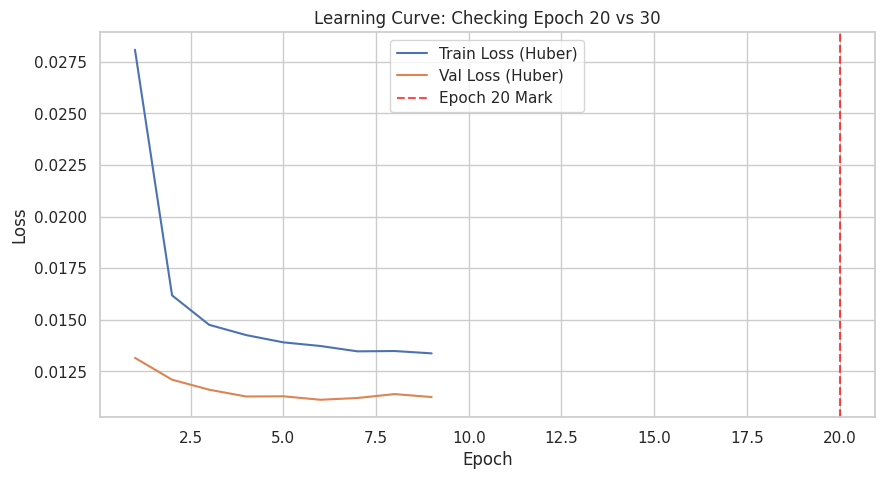

In [45]:
%matplotlib inline

# Get the best parameters from the capacity diagnostics
best_diag = chollet_capacity_regularised_df.iloc[0]

# 1. Setup a single config using your known best grid search parameters
test_cfg = {
    **TR_CFG,
    'epochs': 30,
    'batch_size': min(TR_CFG.get('batch_size', 512), 512),
    'd_model': int(best_diag['d_model']),
    'nhead': int(best_diag['nhead']),
    'num_layers': int(best_diag['num_layers']),
    'ff_dim': int(best_diag['d_model']) * 2,
    'dropout': float(best_diag['dropout']),
    'lr': float(best_diag['lr']),
    'weight_decay': float(best_diag['weight_decay']),
}

print("Running a single 30-epoch test on 100% data to check convergence...")

# 2. Train the model without an Optuna trial object (pass None)
m_test, trl, vll = train_wallet_ae(
    make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=test_cfg['batch_size']),
    make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=test_cfg['batch_size'], shuffle=False),
    test_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device, None
)

# 3. Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(trl) + 1), trl, label='Train Loss (Huber)')
plt.plot(range(1, len(vll) + 1), vll, label='Val Loss (Huber)')

# Draw a line at epoch 20 to easily compare visual differences
plt.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Epoch 20 Mark')

plt.title("Learning Curve: Checking Epoch 20 vs 30")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Paths to SQLite databases
db_paths = [
    '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t.db',
    '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db',
    '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_if.db'
]

for path in db_paths:
    storage_url = f'sqlite:///{path}'
    storage = RDBStorage(url=storage_url)
    try:
        print(f"Checking storage: {path}")
        summaries = optuna.get_all_study_summaries(storage=storage)
        if not summaries:
            print("  No studies found.")
        for summary in summaries:
            optuna.delete_study(study_name=summary.study_name, storage=storage)
            print(f"  -> Deleted study '{summary.study_name}'")
    except Exception as e:
        print(f"  Could not process storage: {e}")

Checking storage: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t.db
  No studies found.
Checking storage: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db
  -> Deleted study 'vastaifloans_AE'
Checking storage: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_if.db
  No studies found.


In [ ]:
def clear_memory():
    """Clears Python garbage collector and PyTorch CUDA cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Memory cleared (GC + CUDA Cache).")

# Execute immediately
clear_memory()

In [ ]:
DB_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db'
storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    study = optuna.load_study(study_name='vastaifloans_AE', storage=storage)
    trials = study.get_trials(deepcopy=False)

    if trials:
        last_trial = max(trials, key=lambda t: t.number)
        print(f'Targeting trial for removal: Number {last_trial.number} (ID: {last_trial._trial_id})')

        # Access the underlying storage directly to bypass _CachedStorage wrapper
        actual_storage = study.storage
        while hasattr(actual_storage, '_backend'):
            actual_storage = actual_storage._backend

        actual_storage.delete_study_trial(study._study_id, last_trial._trial_id)
        print(f'Successfully deleted Trial {last_trial.number}.')
    else:
        print('No trials found.')
except Exception as e:
    print(f'Error: {e}')


## RELOAD PREREQUISITES


## Redefining Objective to ensure it is in scope


In [17]:
try:
    import optuna
    from optuna.storages import RDBStorage
except ImportError:
    raise ImportError('pip install optuna')



if 'chollet_capacity_regularised_df' not in globals():
    path = os.path.join(CKPT, 'chollet_capacity_regularised_df.pkl')
    if os.path.exists(path):
        chollet_capacity_regularised_df = joblib.load(path)
        print('Reloaded chollet_capacity_regularised_df from checkpoint.')
    else:
        raise RuntimeError(f'Missing chollet_capacity_regularised_df and no checkpoint found at {path}')

# Ensure all required globals exist
for v in ['train_wallet_ae', 'score_wallet_ae', 'TR_CFG',
          'WALLET_INDEX', 'X_tx_norm', 'train_wallets', 'val_wallets', 'test_wallets',
          'tx_feature_cols', 'MAX_SEQ_LEN', 'device', 'chollet_capacity_regularised_df', 'make_wallet_loader']:
    if v not in globals():
        raise RuntimeError(f'Missing: {v}')

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optimization config
OPTUNA_N_TRIALS = 150
OPTUNA_TIMEOUT = 3600
OPTUNA_APPLY_BEST = True
DB_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db'

# Search space configuration (Restoring from previous run state)
best_diag = chollet_capacity_regularised_df.iloc[0]
c_d = int(best_diag['d_model'])
c_l = int(best_diag['num_layers'])
c_dr = float(best_diag['dropout'])
c_lr = float(best_diag['lr'])
c_wd = float(best_diag['weight_decay'])

d_model_choices = sorted(set([max(16, c_d // 2), c_d, min(256, c_d * 2)]))
layer_choices = [max(1, c_l - 1), c_l, c_l + 1]

def optuna_objective_ae(trial):
    t0 = time.time()
    print(f'Starting AE Trial {trial.number + 1}/{OPTUNA_N_TRIALS}...')

    d = int(trial.suggest_categorical('ae_d_model', d_model_choices))
    tr_cfg = {
        **TR_CFG, 'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d,
        'nhead': int(trial.suggest_categorical('ae_nhead', [h for h in [2, 4, 8] if d % h == 0])),
        'num_layers': int(trial.suggest_int('ae_num_layers', layer_choices[0], layer_choices[-1])),
        'ff_dim': d * int(trial.suggest_int('ae_ff_mult', 2, 4)),
        'dropout': float(trial.suggest_float('ae_dropout', max(0.0, c_dr - 0.15), min(0.5, c_dr + 0.20))),
        'lr': float(trial.suggest_float('ae_lr', c_lr / 10, c_lr * 10, log=True)),
        'weight_decay': float(trial.suggest_float('ae_weight_decay', max(1e-8, c_wd / 100), min(1e-2, c_wd * 100), log=True)),
    }

    m, trl, vll = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=tr_cfg['batch_size'], shuffle=False),
        tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device, trial)

    raw_val, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, val_wallets.tolist(), MAX_SEQ_LEN, device, tx_feature_cols)
    raw_test, _ = score_wallet_ae(m, X_tx_norm, WALLET_INDEX, test_wallets.tolist(), MAX_SEQ_LEN, device, tx_feature_cols)

    val_hub = float(vll[-1]) if vll else 1e6
    gen_gap = max(0.0, val_hub - (float(trl[-1]) if trl else 1e6))
    val_tail_contrast = float(np.quantile(raw_val, 0.99) - np.quantile(raw_val, 0.50))
    val_test_gap = float(np.mean(raw_test) - np.mean(raw_val))

    trial.set_user_attr('val_tail_contrast', val_tail_contrast)
    trial.set_user_attr('val_test_gap', val_test_gap)
    trial.set_user_attr('val_huber', val_hub)
    trial.set_user_attr('gen_gap', gen_gap)

    del m; torch.cuda.empty_cache(); gc.collect()

    score = float(0.40 * val_tail_contrast + 0.30 * val_test_gap - 0.15 * np.log1p(val_hub * 100) - 0.15 * np.log1p(gen_gap * 100))
    elapsed = time.time() - t0
    print(f'Trial {trial.number + 1} finished in {elapsed:.1f}s. Score: {score:.4f}')
    return score

# AE study with persistent RDBStorage
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')
optuna_study_ae = optuna.create_study(
    study_name='vastaifloans_AE',
    storage=ae_storage,
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, constant_liar=True),
    pruner=optuna.pruners.HyperbandPruner(min_resource=1, max_resource=30, reduction_factor=4)
)

completed_trials = len([t for t in optuna_study_ae.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Resuming study. Progress: {completed_trials}/{OPTUNA_N_TRIALS}')

# Enqueue the best known configuration as a "ghost" trial to anchor the search
if completed_trials == 0:
    optuna_study_ae.enqueue_trial({
        'ae_d_model': c_d,
        'ae_nhead': int(best_diag['nhead']),
        'ae_num_layers': c_l,
        'ae_ff_mult': 2,  # equivalent to ff_dim = d_model * 2
        'ae_dropout': c_dr,
        'ae_lr': c_lr,
        'ae_weight_decay': c_wd
    })

if completed_trials < OPTUNA_N_TRIALS:
    optuna_study_ae.optimize(
        optuna_objective_ae,
        n_trials=OPTUNA_N_TRIALS - completed_trials,
        timeout=OPTUNA_TIMEOUT,
        n_jobs=10,
        gc_after_trial=True
    )

Reloaded chollet_capacity_regularised_df from checkpoint.
Resuming study. Progress: 27/150
Starting AE Trial 144/150...
Starting AE Trial 146/150...
Starting AE Trial 149/150...
Starting AE Trial 147/150...
Starting AE Trial 145/150...
Starting AE Trial 150/150...
Starting AE Trial 143/150...
Starting AE Trial 148/150...
Starting AE Trial 152/150...
Starting AE Trial 151/150...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in memory...
Pre-computing and caching 122696 wallet sequences in

KeyboardInterrupt: 

In [18]:
# 1. Connect to the existing study storage
DB_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db'
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    # 2. Load the study
    study = optuna.load_study(study_name='vastaifloans_AE', storage=ae_storage)
    best_trial = study.best_trial
    print(f"Best Trial Number: {best_trial.number}")
    print(f"Best Value: {best_trial.value:.4f}")

    # 3. Reconstruct the best configuration
    # Note: ff_mult was suggested as a multiplier in the objective
    best_params = best_trial.params
    d_model = int(best_params['ae_d_model'])

    best_tr_cfg = {
        **TR_CFG,
        'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d_model,
        'nhead': int(best_params['ae_nhead']),
        'num_layers': int(best_params['ae_num_layers']),
        'ff_dim': d_model * int(best_params['ae_ff_mult']),
        'dropout': float(best_params['ae_dropout']),
        'lr': float(best_params['ae_lr']),
        'weight_decay': float(best_params['ae_weight_decay'])
    }

    # 4. Retrain or Initialize the best model
    print("Retraining best model on full train set...")
    ae_optuna_optimised, _, _ = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, train_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, val_wallets.tolist(), tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size'], shuffle=False),
        best_tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device
    )

    print(f"Success: 'ae_optuna_optimised' created using best params from Trial {best_trial.number}")

except Exception as e:
    print(f"CRITICAL: Failed to load best model from Optuna study. Error: {e}")

Best Trial Number: 51
Best Value: -0.0679
Retraining best model on full train set...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 9/30  train=0.018497  val=0.014615
  Epoch 1/30  train=0.026552  val=0.013030
  Epoch 10/30  train=0.018267  val=0.014894
  Early stop at epoch 10. Restoring best weights.
Optimal training stopped at epoch 10. Best weights were from epoch 7.
  Epoch 2/30  train=0.015823  val=0.011494
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
  Epoch 3/30  train=0.014627  val=0.011472
Pre-computing and caching 172775 walle

In [19]:
# Connect to the AE study storage
DB_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db'
storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    study = optuna.load_study(study_name='vastaifloans_AE', storage=storage)

    # Get distribution of states
    df = study.trials_dataframe()
    if not df.empty:
        stats = df['state'].value_counts().to_frame().reset_index()
        stats.columns = ['Trial State', 'Count']

        print(f"Study Name: {study.study_name}")
        print(f"Total trials initiated: {len(df)}")
        display(stats)

        if 'state' in df.columns and (df['state'] == 'COMPLETE').any():
             print(f"Best score so far: {study.best_value:.4f}")
    else:
        print("No trials found in the database.")

except Exception as e:
    print(f"Error accessing study: {e}")

Study Name: vastaifloans_AE
Total trials initiated: 162


,Trial State,Count
0,PRUNED,122
1,COMPLETE,30
2,RUNNING,10


Best score so far: -0.0679


In [20]:
# 1. Connect to the existing study storage
DB_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_ae.db'
AE_CKPT_PATH = os.path.join(CKPT, 'ae_model.pt')
ae_storage = RDBStorage(url=f'sqlite:///{DB_PATH}')

try:
    # 2. Ensure dependencies are defined
    if 'WalletTransformerAE' not in globals():
        print("Architecture not found in globals. Please ensure cells RDhoiZYeo4cR and 21yQUwuTo4cQ ran.")

    # 3. Load the study
    study = optuna.load_study(study_name='vastaifloans_AE', storage=ae_storage)
    best_trial = study.best_trial
    print(f"Best Trial Number: {best_trial.number}")

    # 4. Config Restoration
    if 'TR_CFG' not in globals():
        if os.path.exists(AE_CKPT_PATH):
            _tmp_ckpt = torch.load(AE_CKPT_PATH, map_location='cpu')
            TR_CFG = _tmp_ckpt['cfg']
        else:
            TR_CFG = dict(d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.10, lr=1e-3, weight_decay=1e-4, epochs=30, batch_size=512, mask_ratio=0.15)

    best_params = best_trial.params
    d_model = int(best_params['ae_d_model'])
    best_tr_cfg = {
        **TR_CFG,
        'epochs': 30,
        'batch_size': min(TR_CFG.get('batch_size', 512), 512),
        'd_model': d_model,
        'nhead': int(best_params['ae_nhead']),
        'num_layers': int(best_params['ae_num_layers']),
        'ff_dim': d_model * int(best_params['ae_ff_mult']),
        'dropout': float(best_params['ae_dropout']),
        'lr': float(best_params['ae_lr']),
        'weight_decay': float(best_params['ae_weight_decay'])
    }

    # 5. Type safety for wallet lists
    tw_list = list(train_wallets) if not isinstance(train_wallets, list) else train_wallets
    vw_list = list(val_wallets) if not isinstance(val_wallets, list) else val_wallets

    # 6. Retrain
    print("Retraining best model on full train set...")
    ae_optuna_optimised, _, _ = train_wallet_ae(
        make_wallet_loader(X_tx_norm, WALLET_INDEX, tw_list, tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size']),
        make_wallet_loader(X_tx_norm, WALLET_INDEX, vw_list, tx_feature_cols, MAX_SEQ_LEN, batch_size=best_tr_cfg['batch_size'], shuffle=False),
        best_tr_cfg, len(tx_feature_cols), MAX_SEQ_LEN, device
    )

    print(f"Success: 'ae_optuna_optimised' created using Trial {best_trial.number}")

except Exception as e:
    print(f"CRITICAL Error: {e}")

Best Trial Number: 51
Retraining best model on full train set...
Pre-computing and caching 122696 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Pre-computing and caching 152071 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Model initialized and moved to explicit device: cuda:0
  Epoch 1/30  train=0.030814  val=0.013415
  Epoch 2/30  train=0.016321  val=0.011991
  Epoch 3/30  train=0.014704  val=0.011431
  Epoch 4/30  train=0.014176  val=0.011280
  Epoch 5/30  train=0.013851  val=0.011137
  Epoch 6/30  train=0.013779  val=0.011093
  Epoch 7/30  train=0.013541  val=0.011121
  Epoch 8/30  train=0.013749  val=0.011080
  Early stop at epoch 8. Restoring best weights.
Optimal training stopped at epoch 8. Best weights were from epoch 5.
Success: 'ae_optuna_optimised' created using Trial 51


## Save Optimized AE Model


In [21]:
if 'ae_optuna_optimised' in globals():
    # Prepare the checkpoint payload using the best configuration and model state
    checkpoint = {
        'state_dict': ae_optuna_optimised.state_dict(),
        'cfg': best_tr_cfg if 'best_tr_cfg' in globals() else TR_CFG,
        'trial_number': best_trial.number if 'best_trial' in globals() else None
    }

    save_path = os.path.join(CKPT, 'ae_model_optimised.pt')
    torch.save(checkpoint, save_path)
    print(f'Successfully saved optimized model to: {save_path}')
else:
    print('ERROR: ae_optuna_optimised not found in memory. Please ensure cell iJBNTCduDj1G has completed.')

Successfully saved optimized model to: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/ae_model_optimised.pt


## Isolation Forest Testing (cuML / FIL Backend)


In [23]:
# 1. Initialize and Fit (Using the cuML-wrapped class from cell U2xIvpE5o4cN)
print(f"Fitting Isolation Forest on {train_mask_tx.sum():,} transactions...")
if_test_model = IsolationForest(
    n_estimators=100,
    max_samples=1024,
    contamination='auto',
    random_state=42
)
if_test_model.fit(X_tx[train_mask_tx])

# 2. GPU-Accelerated Inference via cuML FIL
print("Scoring entire dataset via GPU...")
# The .decision_function() in our wrapper uses self._fil.predict if _HAS_FIL is True
if_raw_scores = -if_test_model.decision_function(X_tx)

# 3. Structural Knee Detection (Data-Driven Thresholding)
raw_train = if_raw_scores[train_mask_tx]
median_val = np.median(raw_train)
upper_half = np.sort(raw_train[raw_train > median_val])

kneedle = KneeLocator(
    np.arange(len(upper_half)),
    upper_half,
    S=1.0,
    curve='convex',
    direction='increasing'
)

if kneedle.knee:
    optimal_threshold = upper_half[kneedle.knee]
    flag_rate = (if_raw_scores[test_mask_tx] >= optimal_threshold).mean()
    print(f"\nIF Results:")
    print(f"- Structural Threshold : {optimal_threshold:.6f}")
    print(f"- Test Set Flag Rate   : {flag_rate*100:.2f}%")
    print(f"- cuML FIL Active      : {if_test_model._fil is not None}")
else:
    print("Knee detection failed to find a distinct structural break.")

# 4. CDF Normalization for the IF component
if_train_sorted = np.sort(raw_train)
if_cdf_scores = np.searchsorted(if_train_sorted, if_raw_scores, side='right') / len(if_train_sorted)
print(f"IF CDF Stats - Mean: {if_cdf_scores.mean():.4f}, Max: {if_cdf_scores.max():.4f}")

Fitting Isolation Forest on 500,791 transactions...
Scoring entire dataset via GPU...

IF Results:
- Structural Threshold : 0.074314
- Test Set Flag Rate   : 0.43%
- cuML FIL Active      : True
IF CDF Stats - Mean: 0.6699, Max: 1.0000


In [ ]:
"""import optuna

# Path to the IF Optuna study database
IF_DB = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_if.db'
storage_url = f'sqlite:///{IF_DB}'
storage = RDBStorage(url=storage_url)

try:
    print(f"Accessing storage: {IF_DB}")
    # Attempt to delete the specific IF study
    optuna.delete_study(study_name='vastaifloans_150T_IF', storage=storage)
    print("Successfully deleted study: vastaifloans_150T_IF")
except Exception as e:
    print(f"Study 'vastaifloans_150T_IF' not found or could not be deleted: {e}")

# Optional: Check if any other studies exist in this DB file
try:
    summaries = optuna.get_all_study_summaries(storage=storage)
    if summaries:
        print(f"Remaining studies in DB: {[s.study_name for s in summaries]}")
    else:
        print("No other studies found in the database.")
except Exception as e:
    print(f"Could not fetch study summaries: {e}")"""

## Isolation Forest Standalone Optimization


In [24]:
# Using the cuML-backed IsolationForest class for GPU acceleration

OPTUNA_N_TRIALS = 50

def _optuna_objective_if(trial):
    t0 = time.time()
    print(f'Starting IF Trial {trial.number}...')

    # Subsample training wallets to speed up trials and ensure diversity
    _sub_w = np.random.default_rng(trial.number + 99).choice(train_wallets, size=len(train_wallets)//2, replace=False).tolist()
    _sub_tx = df_flat['wallet'].is_in(_sub_w).to_numpy() & train_mask_tx

    current_train_size = int(_sub_tx.sum())

    # Initialize our custom IF wrapper (leveraging cuML/FIL internally)
    model = IsolationForest(
        n_estimators=trial.suggest_int('if_n_estimators', 100, 1000, step=50),
        max_samples=min(int(trial.suggest_categorical('if_max_samples', [128, 256, 512, 1024, 2048])), current_train_size),
        contamination=trial.suggest_float('if_contamination', 0.005, 0.05),
        random_state=42
    )

    # Fit on GPU/CPU and score
    model.fit(X_tx[_sub_tx])
    if_raw = -model.decision_function(X_tx)

    # CDF Normalization relative to current trial train set
    if_train_sorted = np.sort(if_raw[_sub_tx])
    if_tx_s = np.searchsorted(if_train_sorted, if_raw, side='right') / len(if_train_sorted)

    # Aggregate to wallet-level for validation metric (Signal Spread)
    _vw = val_wallets.tolist()
    # Efficient max-pooling using Polars
    if_wal_val = (pl.DataFrame({'w': df_flat['wallet'], 's': if_tx_s})
                  .filter(pl.col('w').is_in(_vw))
                  .group_by('w')
                  .agg(pl.col('s').max())
                  .to_pandas().set_index('w')
                  .reindex(_vw, fill_value=0.0)['s'].values)

    # Metric: Distance between p99 and Median in log-space (Detectability of outliers)
    if_spread = float(np.log1p(np.quantile(if_wal_val, 0.99)) - np.log1p(np.median(if_wal_val) + 1e-8))
    trial.set_user_attr('if_spread', if_spread)

    elapsed = time.time() - t0
    print(f'  Trial {trial.number} finished in {elapsed:.2f}s | Spread: {if_spread:.4f}')
    return if_spread

# Persistent Study on Drive
IF_DB = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/optuna_study_150t_if.db'
if_storage = RDBStorage(url=f'sqlite:///{IF_DB}')

optuna_study_if = optuna.create_study(
    study_name='vastaifloans_150T_IF',
    storage=if_storage,
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True)
)

# Run optimization
optuna_study_if.optimize(
    _optuna_objective_if,
    n_trials=max(0, OPTUNA_N_TRIALS - len(optuna_study_if.trials)),
    timeout=1800, # 30 mins
    gc_after_trial=True
)

# Finalize best configuration
best_if = optuna_study_if.best_trial
optuna_best_if_cfg = {**{k[3:]: v for k, v in best_if.params.items() if k.startswith('if_')}, 'random_state': 42}

print(f"\nOptimization Complete.")
print(f"Best IF Config: {optuna_best_if_cfg}")
print(f"Best Spread Score: {best_if.value:.4f}")

Starting IF Trial 0...
  Trial 0 finished in 2.38s | Spread: 0.3266
Starting IF Trial 1...
  Trial 1 finished in 5.42s | Spread: 0.2709
Starting IF Trial 2...
  Trial 2 finished in 1.85s | Spread: 0.3143
Starting IF Trial 3...
  Trial 3 finished in 1.77s | Spread: 0.3507
Starting IF Trial 4...
  Trial 4 finished in 6.26s | Spread: 0.3803
Starting IF Trial 5...
  Trial 5 finished in 5.39s | Spread: 0.3723
Starting IF Trial 6...
  Trial 6 finished in 0.97s | Spread: 0.3559
Starting IF Trial 7...
  Trial 7 finished in 1.80s | Spread: 0.3832
Starting IF Trial 8...
  Trial 8 finished in 1.47s | Spread: 0.3441
Starting IF Trial 9...
  Trial 9 finished in 2.63s | Spread: 0.2682
Starting IF Trial 10...
  Trial 10 finished in 1.10s | Spread: 0.4349
Starting IF Trial 11...
  Trial 11 finished in 1.43s | Spread: 0.3566
Starting IF Trial 12...
  Trial 12 finished in 3.45s | Spread: 0.3937
Starting IF Trial 13...
  Trial 13 finished in 3.48s | Spread: 0.3869
Starting IF Trial 14...
  Trial 14 finis

## Save Optimized IF Configuration


In [25]:
if 'optuna_study_if' in globals():
    try:
        # Extract best parameters and format for IsolationForest init
        best_if_trial = optuna_study_if.best_trial
        if_results = {
            'params': {k[3:]: v for k, v in best_if_trial.params.items() if k.startswith('if_')},
            'value': best_if_trial.value,
            'number': best_if_trial.number,
            'user_attrs': best_if_trial.user_attrs
        }

        save_path = os.path.join(CKPT, 'if_model_optimised.pkl')
        joblib.dump(if_results, save_path)
        print(f"Successfully saved best IF results (Trial {best_if_trial.number}) to: {save_path}")
        print(f"Best Params: {if_results['params']}")
    except Exception as e:
        print(f"Error saving IF results: {e}")
else:
    print("ERROR: 'optuna_study_if' not found. Please run the IF optimization cell (_Z8qOvqRo4cS) first.")

Successfully saved best IF results (Trial 37) to: /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_model_optimised.pkl
Best Params: {'n_estimators': 150, 'max_samples': 128, 'contamination': 0.04211115700391119}


In [26]:
"""iforest.decision_function(X_tx)
if_train_sort = np.sort(if_raw[train_mask_tx])
if_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)
"""

"iforest.decision_function(X_tx)\nif_train_sort = np.sort(if_raw[train_mask_tx])\nif_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)\n"

In [ ]:
# Define the checkpoint path
AE_OPTIMISED_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/ae_model_optimised.pt'

if os.path.exists(AE_OPTIMISED_PATH):
    try:
        # 1. Load the checkpoint file
        checkpoint = torch.load(AE_OPTIMISED_PATH, map_location='cpu')

        # 2. Extract configuration
        saved_cfg = checkpoint['cfg']
        print(f"Loading model from Trial {checkpoint.get('trial_number', 'Unknown')}")
        print(f"Configuration: {saved_cfg}")

        # 3. Initialize the model architecture
        # Ensure WalletTransformerAE class is defined in the notebook session
        n_features = X_tx_norm.shape[1] if 'X_tx_norm' in globals() else 25

        ae_optuna_optimised = WalletTransformerAE(
            n_features=n_features,
            d_model=saved_cfg['d_model'],
            nhead=saved_cfg['nhead'],
            num_layers=saved_cfg['num_layers'],
            ff_dim=saved_cfg['ff_dim'],
            dropout=saved_cfg['dropout'],
            max_seq_len=MAX_SEQ_LEN if 'MAX_SEQ_LEN' in globals() else 64
        )

        # 4. Load state dict and set to eval mode
        ae_optuna_optimised.load_state_dict(checkpoint['state_dict'])
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        ae_optuna_optimised = ae_optuna_optimised.to(device).eval()

        print(f"\nSuccess: Optimized AE model loaded and moved to {device}.")

    except Exception as e:
        print(f"Error loading the model: {e}")
else:
    print(f"CRITICAL: Checkpoint not found at {AE_OPTIMISED_PATH}. Please verify the path.")

In [28]:
ae_model_optimised

WalletTransformerAE(
  (input_proj): Linear(in_features=25, out_features=32, bias=True)
  (pos_embed): Embedding(64, 32)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.08641094584558795, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.08641094584558795, inplace=False)
        (dropout2): Dropout(p=0.08641094584558795, inplace=False)
      )
    )
  )
  (out_proj): Linear(in_features=32, out_features=25, bias=True)
)

## 0. Load Best Params from Drive


In [32]:
IF_CKPT_PATH = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_model_optimised.pkl'
if os.path.exists(IF_CKPT_PATH):
    if_results = joblib.load(IF_CKPT_PATH)
    print(f"Loaded IF optimization results from {IF_CKPT_PATH}")
else:
    raise FileNotFoundError(f"CRITICAL: Could not find optimized IF results at {IF_CKPT_PATH}")

# 1. Isolation Forest Scoring
print('Fitting Optimized Isolation Forest...')
# Re-initialize using loaded params
iforest = IsolationForest(
    n_estimators=if_results['params']['n_estimators'],
    max_samples=if_results['params']['max_samples'],
    contamination=if_results['params']['contamination'],
    random_state=42
).fit(X_tx[train_mask_tx])

print('Generating IF CDF scores...')
if_raw = -iforest.decision_function(X_tx)
if_train_sort = np.sort(if_raw[train_mask_tx])
if_tx_score = np.searchsorted(if_train_sort, if_raw, side='right') / len(if_train_sort)

# 2. Transformer AE CDF Scoring
print('Generating AE CDF scores...')
ae_model_optimised.eval()
all_wallets = df_flat['wallet'].unique().to_list()

# Get raw wallet-level reconstruction errors
ae_scores, _ = score_wallet_ae(
    ae_model_optimised, X_tx_norm, WALLET_INDEX, all_wallets, MAX_SEQ_LEN, device, tx_feature_cols
)

# Regenerate wallet masks for downstream stability checks
all_wallets_np = np.array(all_wallets)
val_w_mask = np.isin(all_wallets_np, np.array(val_wallets))
test_w_mask = np.isin(all_wallets_np, np.array(test_wallets))

# Calculate CDF based on training wallets only
_train_w_mask = np.isin(all_wallets_np, np.array(train_wallets))
tr_train_sort = np.sort(ae_scores[_train_w_mask])
tr_wallet_cdf = np.searchsorted(tr_train_sort, ae_scores, side='right') / len(tr_train_sort)

# Map wallet scores to transaction level
wallet_to_tr_cdf = dict(zip(all_wallets, tr_wallet_cdf))
tr_tx_score = np.array([wallet_to_tr_cdf[w] for w in df_flat['wallet']], dtype=np.float32)

print(f'Done. IF Mean CDF: {if_tx_score.mean():.4f} | AE Mean CDF: {tr_tx_score.mean():.4f}')

Loaded IF optimization results from /content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_model_optimised.pkl
Fitting Optimized Isolation Forest...
Generating IF CDF scores...
Generating AE CDF scores...
Pre-computing and caching 619160 wallet sequences in memory...
Caching complete!
Creating DataLoader: batch_size=512, pin_memory=True, num_workers=0, cached=True
Done. IF Mean CDF: 0.6667 | AE Mean CDF: 0.6037


In [33]:
if 'if_tx_score' in globals() and 'val_mask_tx' in globals() and 'test_mask_tx' in globals():
    val_mean = if_tx_score[val_mask_tx].mean()
    test_mean = if_tx_score[test_mask_tx].mean()
    ratio = test_mean / val_mean if val_mean != 0 else 0

    print(f'--- Isolation Forest Stability ---')
    print(f'Validation Mean Score : {val_mean:.4f}')
    print(f'Test Mean Score       : {test_mean:.4f}')
    print(f'Test/Val Ratio        : {ratio:.4f}')

    if abs(1 - ratio) > 0.15:
        print('WARNING: High drift detected between Val and Test distributions.')
    else:
        print('STABLE: Distribution remains consistent across splits.')
else:
    print('ERROR: if_tx_score or split masks not found in memory.')

--- Isolation Forest Stability ---
Validation Mean Score : 0.4789
Test Mean Score       : 0.6276
Test/Val Ratio        : 1.3106


In [34]:
if 'ae_scores' in globals() and 'val_w_mask' in globals() and 'test_w_mask' in globals():
    ae_val_mean = ae_scores[val_w_mask].mean()
    ae_test_mean = ae_scores[test_w_mask].mean()
    ae_ratio = ae_test_mean / ae_val_mean if ae_val_mean != 0 else 0

    print(f'--- Transformer AE Stability ---')
    print(f'Validation Mean Score : {ae_val_mean:.6f}')
    print(f'Test Mean Score       : {ae_test_mean:.6f}')
    print(f'Test/Val Ratio        : {ae_ratio:.4f}')

    if abs(1 - ae_ratio) > 0.15:
        print('WARNING: Significant drift detected between AE Val and Test distributions.')
    else:
        print('STABLE: AE distribution remains consistent across splits.')
else:
    # Fallback if ae_scores isn\'t globally available, using the tr_wallet_raw from the scoring pass
    if 'tr_wallet_raw' in globals():
        val_res = tr_wallet_raw[np.isin(all_wallets, val_wallets)].mean()
        test_res = tr_wallet_raw[np.isin(all_wallets, test_wallets)].mean()
        print(f'--- Transformer AE Stability (from tr_wallet_raw) ---')
        print(f'Val Mean: {val_res:.6f} | Test Mean: {test_res:.6f} | Ratio: {test_res/val_res:.4f}')
    else:
        print('ERROR: AE scores or split masks not found. Please run the AE scoring cell first.')

--- Transformer AE Stability ---
Validation Mean Score : 0.127538
Test Mean Score       : 0.128212
Test/Val Ratio        : 1.0053
STABLE: AE distribution remains consistent across splits.


In [36]:
# Ensure checkpoint directory exists

# 1. Save normalized score arrays (Transaction-level)
if 'if_tx_score' in globals():
    np.save(os.path.join(CKPT, 'if_tx_score.npy'), if_tx_score)
    print("Saved: if_tx_score.npy")

if 'tr_tx_score' in globals():
    np.save(os.path.join(CKPT, 'tr_tx_score.npy'), tr_tx_score)
    print("Saved: tr_tx_score.npy")

if 'combined_tx_score' in globals():
    np.save(os.path.join(CKPT, 'combined_tx_score.npy'), combined_tx_score)
    print("Saved: combined_tx_score.npy")

# 2. Save aggregated wallet-level scores
if 'wallet_scores' in globals():
    wallet_scores.to_parquet(os.path.join(CKPT, 'wallet_scores_final.parquet'), index=False)
    print("Saved: wallet_scores_final.parquet")
"""
# 3. Save model components if newly trained
if 'iforest' in globals():
    print("Saved: iforest.pkl")
"""
print("\nAll current pipeline artifacts have been successfully saved to Google Drive.")

Saved: if_tx_score.npy
Saved: tr_tx_score.npy

All current pipeline artifacts have been successfully saved to Google Drive.


## Reload Pipeline State from Google Drive


In [17]:
# 1. Load Scaler and Normalized Features
try:
    scaler = joblib.load(os.path.join(CKPT, 'scaler.pkl'))
    X_tx_norm = np.load(os.path.join(CKPT, 'X_tx_norm.npy'))
    print(f"Scaler and X_tx_norm ({X_tx_norm.shape}) loaded.")
except Exception as e:
    print(f"Error loading base features: {e}")

# 2. Load Models (IF and Optimized AE)
try:
    iforest = joblib.load(os.path.join(CKPT, 'if_model_optimised.pkl'))
    print("Isolation Forest reloaded.")

    _ae_ckpt = torch.load(os.path.join(CKPT, 'ae_model_optimised.pt'), map_location='cpu')
    TR_CFG = _ae_ckpt['cfg']
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Filter out training-specific keys
    model_kwargs = {k: v for k, v in TR_CFG.items() if k not in ['epochs', 'lr', 'weight_decay', 'batch_size']}
    ae_optuna_optimised = WalletTransformerAE(n_features=X_tx_norm.shape[1], **model_kwargs)
    ae_optuna_optimised.load_state_dict(_ae_ckpt['state_dict'])
    ae_optuna_optimised = ae_optuna_optimised.to(device).eval()
    print(f"Optimized Transformer AE loaded on {device}.")
except Exception as e:
    print(f"Error loading models: {e}")

# 3. Load Normalized Score Arrays
try:
    if_tx_score = np.load(os.path.join(CKPT, 'if_tx_score.npy'))
    tr_tx_score = np.load(os.path.join(CKPT, 'tr_tx_score.npy'))
    combined_tx_score = np.load(os.path.join(CKPT, 'combined_tx_score.npy'))
    print("Normalized score arrays loaded.")
except Exception as e:
    print(f"Error loading score arrays: {e}")

# 4. Load Scored Wallet DataFrame
try:
    wallet_scores = pl.read_parquet(os.path.join(CKPT, 'wallet_scores_final.parquet')).to_pandas()
    print(f"Wallet scores loaded: {wallet_scores.shape}")
except Exception as e:
    print(f"Error loading wallet scores: {e}")

print("\n=== Environment Restored ===")

Scaler and X_tx_norm ((2905990, 25)) loaded.
Isolation Forest reloaded.
Error loading models: WalletTransformerAE.__init__() got an unexpected keyword argument 'lr'
Error loading score arrays: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/if_tx_score.npy'
Error loading wallet scores: No such file or directory (os error 2): ...ontent/drive/MyDrive/Colab Notebooks/vastaiFinal/checkpoints/wallet_scores_final.parquet (set POLARS_VERBOSE=1 to see full path)

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'


=== Environment Restored ===


## 1. Reload Prerequisites


## 2. Ensemble Scoring Logic (MoA - Max of Averages)


## 3. Wallet-Level Aggregation (Max-Pooling)


In [37]:
CACHE = '/content/drive/MyDrive/Colab Notebooks/vastaiFinal/engineered_features_cache.parquet'
if 'df_flat' not in globals():
    if os.path.exists(CACHE):
        print(f"Reloading df_flat from {CACHE}...")
        df_flat = pl.read_parquet(CACHE)
    else:
        raise FileNotFoundError(f"CRITICAL: Cache not found at {CACHE}")

W_IF, W_AE = 0.5, 0.5

print("Calculating Ensemble Scores (MoA Strategy)...")

if 'if_tx_score' in globals() and 'tr_tx_score' in globals():
    combined_tx_score = (W_IF * if_tx_score) + (W_AE * tr_tx_score)

    df_flat = df_flat.with_columns([
        pl.Series('combined_score', combined_tx_score)
    ])

    wallet_ensemble = (
        df_flat.group_by('wallet')
        .agg([
            pl.col('combined_score').max().alias('max_risk_score'),
            pl.col('combined_score').mean().alias('avg_risk_score'),
            pl.len().alias('tx_count')
        ])
        .to_pandas()
    )

    print(f"Ensemble complete for {len(wallet_ensemble):,} wallets.")

    # Standardize names for downstream conformal prediction
    wallet_scores = wallet_ensemble.rename(columns={'max_risk_score': 'raw_score'})

    print("\nTop 10 High-Risk Wallets (MoA):")
    display(wallet_scores.nlargest(10, 'raw_score'))

else:
    print("CRITICAL: Normalized scores not found. Please ensure scoring pass has completed.")

Calculating Ensemble Scores (MoA Strategy)...
Ensemble complete for 619,160 wallets.

Top 10 High-Risk Wallets (MoA):


,wallet,raw_score,avg_risk_score,tx_count
296619,A7fhLJaYmpovdTLtTXyZijrro996zfLik5xv7QuckGZD,0.999957,0.999957,1
510906,FyeAE59et5tbzaudSmi3p3XHq9Y7Zid3g8514MZT7E8o,0.999902,0.999902,1
471975,EuKXybPU6QJrE7JPWoZhBBdQcwBtkprKmBQQt4T4ff9e,0.999873,0.999873,1
302409,AGgUVH68jcsHdxssm1H4pUW56nHqSRcEfgQv488jn1AK,0.999865,0.999865,1
77283,45q8atWAv8REJsz7Je2ty1UiteGWKAsEGvSm6soZAkJB,0.999827,0.999827,1
126683,5SwtDXGaVpFbpzXX1zbXt7Ku2ZX17SRwwVaALrao5KpJ,0.999804,0.999804,1
180791,6wK3dgKvCbNoYQuXMzNnMJgth9SkxnMMyk1Y4hHYL1We,0.999796,0.999796,1
614696,sb2dC8eWBVyzAJUCKYiBVuiTBeuPQCy1oHse6jUWGoG,0.999687,0.999687,1
363740,BwMegxc8JXrXjgeY5R7xaxM98pRs1P7X7Ck933tJKr56,0.999534,0.999534,1
181962,6y8TU3YGPmbCTHchJtKgPeDxH56FvE63eZm6L4SeDrcq,0.999521,0.999521,1


In [39]:
wallet_scores[wallet_scores['tx_count'] > 3]

,wallet,raw_score,avg_risk_score,tx_count
5,11VdEfJY7ktgk4oQrAh28WF3kiAM5GLEnEMrTvMxCsB,0.836980,0.800764,122
32,123JvycEQwHFtXgXtFzh8ExDER7L65bzAqRVRaJpSFtU,0.926448,0.848843,338
171,12HJCRw1jPKjq5S7dGH2bBVBSNim16X2rzzDWcQBuvE3,0.431575,0.364961,15
205,12KPt2hqjmVhnmPsNRw5wVAmWVV2mEtSdRXcJYJeJbt9,0.817654,0.629002,30
225,12LmhgmRiMYPZ5noG8MXaFNVCZq7gFpcZErkgkYumf85,0.911277,0.831372,17
...,...,...,...,...
618969,zeGZU29YSMXJLv3Fow2LH54GRe4dhfBgNtXGESATJcN,0.963365,0.821023,20
618971,zePEWnEAAkzv2NBDQ3sArYJSXBie4FMhuLszPweBm7H,0.955020,0.903476,13
619049,znKtC1CxfqYR9ACgEJNf4EhyrWd6ponGccNJL9R3P4n,0.275615,0.270170,8
619072,zpqU88UoJTEsRMMYtb3tLkXiZm32GaapAfNeqUieh46,0.938585,0.886769,11


## CDF-based Ensemble


## Wallet-level max pooling


In [40]:
W_IF, W_TR = 0.5, 0.5
all_wallets = df_flat["wallet"].unique().to_list() if hasattr(df_flat, "unique") else df_flat["wallet"].unique().tolist()

wallet_to_tr_cdf = dict(zip(all_wallets, tr_tx_score))
tr_cdf_tx = np.array([wallet_to_tr_cdf.get(w, 0.0) for w in df_flat['wallet']], dtype=np.float32)
combined_tx = W_IF * if_tx_score + W_TR * tr_cdf_tx

if hasattr(df_flat, 'with_columns'):
    df_flat = df_flat.with_columns([
        pl.Series('if_tx_score', if_tx_score),
        pl.Series('tr_tx_score', tr_cdf_tx),
        pl.Series('combined_tx_score', combined_tx),
    ])
    agg_df = df_flat.select(['wallet', 'if_tx_score', 'tr_tx_score', 'combined_tx_score']).to_pandas()
else:
    df_flat['if_tx_score'] = if_tx_score
    df_flat['tr_tx_score'] = tr_cdf_tx
    df_flat['combined_tx_score'] = combined_tx
    agg_df = df_flat[['wallet', 'if_tx_score', 'tr_tx_score', 'combined_tx_score']]

wallet_scores = (pl.from_pandas(agg_df)
    .group_by('wallet')
    .agg([
        pl.col('if_tx_score').max().alias('if_score'),
        pl.col('tr_tx_score').max().alias('tr_score'),
        pl.col('combined_tx_score').max().alias('raw_score'),
        pl.col('combined_tx_score').count().alias('n_tx'),
    ])).to_pandas()

print(f'Wallet scores: {len(wallet_scores):,}')
print(wallet_scores[['if_score', 'tr_score', 'raw_score']].describe().round(4))


Wallet scores: 619,160
          if_score     tr_score    raw_score
count  619160.0000  619160.0000  619160.0000
mean        0.4735       0.5117       0.4926
std         0.1280       0.4191       0.2192
min         0.1596       0.0000       0.0801
25%         0.4154       0.0138       0.2282
50%         0.4154       0.7307       0.5945
75%         0.4489       0.9272       0.6740
max         1.0000       1.0000       0.9995


## 1. Adaptive Conformal Inference (TorchCP)


## 2. EVT / SPOT (Siffer et al. 2017)


In [93]:
# ── Cell 101: EVT/SPOT → derive alpha → TorchCP ACI ─────────────────────────
import torch
import numpy as np
import scipy.stats as stats
import pickle

try:
    from torchcp.regression.predictor import ACIPredictor
    from torchcp.regression.score import ABS
    has_torchcp = True
except ImportError:
    has_torchcp = False
    print('TorchCP not found: !pip install torchcp')

# ── 1. Split scores ──────────────────────────────────────────────────────────
val_mask_w = wallet_scores['wallet'].isin(val_wallets)
test_mask_w = wallet_scores['wallet'].isin(test_wallets)
cal_scores = wallet_scores.loc[val_mask_w, 'raw_score'].values
test_scores = wallet_scores.loc[test_mask_w, 'raw_score'].values

# ── 2. EVT / SPOT on calibration scores only (no leakage) ───────────────────
q_spot = 0.95
t_spot = np.quantile(cal_scores, q_spot)
exceedances = cal_scores[cal_scores > t_spot] - t_spot

if len(exceedances) > 10:
    shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
    p_target = 1e-3
    if shape != 0:
        z_spot = t_spot + (scale / shape) * (((p_target / (1 - q_spot)) ** (-shape)) - 1)
    else:
        z_spot = t_spot - scale * np.log(p_target / (1 - q_spot))

    TARGET_ALPHA = float(np.mean(cal_scores > z_spot))
    TARGET_ALPHA = np.clip(TARGET_ALPHA, 0.001, 0.20)

    print(f'--- EVT / SPOT (top {100*(1-q_spot):.0f}% of cal scores, p={p_target}) ---')
    print(f'GPD: shape={shape:.4f}, scale={scale:.4f}')
    print(f'EVT threshold: {z_spot:.4f}')
    print(f'Derived alpha: {TARGET_ALPHA:.4f} (fraction of cal > z_spot)')
    print(f'EVT flags on test: {np.sum(test_scores > z_spot)} / {len(test_scores)}')
else:
    print('EVT / SPOT: insufficient exceedances, falling back to alpha=0.05')
    TARGET_ALPHA = 0.05
    z_spot = np.quantile(cal_scores, 1 - TARGET_ALPHA)

ALPHA = TARGET_ALPHA

# ── 3. Rigid (static) conformal baseline ─────────────────────────────────────
rigid_thr = np.quantile(cal_scores, 1 - ALPHA)
rigid_flags = (test_scores > rigid_thr).astype(int)
print(f'\n--- Rigid conformal (α={ALPHA:.4f}) ---')
print(f'Threshold: {rigid_thr:.4f}')
print(f'Flagged: {rigid_flags.sum()} / {len(test_scores)} ({rigid_flags.mean()*100:.2f}%)')

# ── 4. ACI (adaptive conformal) — pre-allocated loop ────────────────────────
test_flags = np.zeros(len(test_scores), dtype=int)
test_pvals = np.ones(len(test_scores), dtype=float)

if has_torchcp:
    print(f'\n--- TorchCP ACI (initial α={ALPHA:.4f}, gamma=0.01) ---')
    scores_val_ts = torch.tensor(cal_scores, dtype=torch.float32).unsqueeze(1)
    scores_test_ts = torch.tensor(test_scores, dtype=torch.float32).unsqueeze(1)

    class DummyModel(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = torch.nn.Linear(1, 1, bias=False)
            torch.nn.init.zeros_(self.linear.weight)
        def forward(self, x):
            return self.linear(x)

    aci_predictor = ACIPredictor(score_function=ABS(), model=DummyModel(), gamma=0.01)
    cal_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.zeros_like(scores_val_ts), scores_val_ts),
        batch_size=len(scores_val_ts)
    )
    aci_predictor.alpha = ALPHA
    aci_predictor.train(cal_loader, epochs=1, lr=0.0)

    # Pre-allocate history buffer (no torch.cat per step)
    LOOKBACK = min(200, len(cal_scores))
    n_cal = len(cal_scores)
    n_test = len(test_scores)
    x_history = torch.zeros(n_cal + n_test, 1)
    y_history = torch.zeros(n_cal + n_test, 1)
    y_history[:n_cal] = scores_val_ts
    hist_len = n_cal

    dynamic_thresholds = np.empty(n_test, dtype=np.float32)

    for t in range(n_test):
        x_t = torch.zeros((1, 1))
        y_t = scores_test_ts[t:t+1]

        lb_start = max(0, hist_len - LOOKBACK)
        prediction = aci_predictor.predict(
            x_t,
            x_lookback=x_history[lb_start:hist_len],
            y_lookback=y_history[lb_start:hist_len],
            update_alpha=True
        )
        upper = prediction[0][0][1].item()

        if y_t.item() > upper:
            test_flags[t] = 1
            test_pvals[t] = ALPHA / 2.0

        dynamic_thresholds[t] = upper
        y_history[hist_len] = y_t
        hist_len += 1

        if (t + 1) % 25000 == 0:
            print(f'  ACI progress: {t+1}/{n_test} ({test_flags[:t+1].sum()} flagged)')

    print(f'Cal: {n_cal}, Test: {n_test}')
    print(f'ACI flagged: {test_flags.sum()} / {n_test} ({test_flags.mean()*100:.2f}%)')
    print(f'Rigid flagged: {rigid_flags.sum()} / {n_test} ({rigid_flags.mean()*100:.2f}%)')
    print(f'Threshold drift: {dynamic_thresholds[0]:.4f} → {dynamic_thresholds[-1]:.4f}')
else:
    print("\nTorchCP not available, using rigid threshold only.")
    test_flags = rigid_flags
    test_pvals = np.where(test_scores > rigid_thr, ALPHA / 2, 1.0)

wallet_scores.loc[test_mask_w, 'conformal_p'] = test_pvals
wallet_scores.loc[test_mask_w, 'conformal_flag'] = test_flags

# ── 5. Save ──────────────────────────────────────────────────────────────────
np.save(CKPT + 'cal_scores.npy', cal_scores)
with open(CKPT + 'alpha.pkl', 'wb') as f:
    pickle.dump(ALPHA, f)
print(f'\nSaved: cal_scores.npy, alpha.pkl (α={ALPHA:.4f})')

--- EVT / SPOT (top 5% of cal scores, p=0.001) ---
GPD: shape=-0.6340, scale=0.1579
EVT threshold: 0.9783
Derived alpha: 0.0010 (fraction of cal > z_spot)
EVT flags on test: 55 / 172775

--- Rigid conformal (α=0.0010) ---
Threshold: 0.9673
Flagged: 171 / 172775 (0.10%)

--- TorchCP ACI (initial α=0.0010, gamma=0.01) ---


Epoch: 100%|██████████| 1/1 [00:02<00:00,  2.26s/it, loss=0.285686]


Training complete.
  ACI progress: 25000/172775 (122 flagged)
  ACI progress: 50000/172775 (253 flagged)
  ACI progress: 75000/172775 (381 flagged)
  ACI progress: 100000/172775 (522 flagged)
  ACI progress: 125000/172775 (649 flagged)
  ACI progress: 150000/172775 (764 flagged)
Cal: 152071, Test: 172775
ACI flagged: 866 / 172775 (0.50%)
Rigid flagged: 171 / 172775 (0.10%)
Threshold drift: 0.9662 → 0.9402

Saved: cal_scores.npy, alpha.pkl (α=0.0010)


## Checkpoint: save combined scores + wallet scores


In [94]:
np.save(CKPT + 'combined_tx_score.npy', combined_tx)
print('Saved: combined_tx_score.npy')

wallet_scores.to_parquet(CKPT + 'wallet_scores.parquet', index=False)
print('Saved: wallet_scores.parquet')

Saved: combined_tx_score.npy
Saved: wallet_scores.parquet


# ── Temporal Decay & Adaptive Conformal Update ────────────────────────────────
# To handle concept drift in non-stationary blockchain environments, a rolling window analysis is implemented.
# A rigid alpha fails under drift; an adaptive alpha adjusts dynamically based on the error rate in the previous window.

## Rolling Window Split


In [95]:
is_polars = hasattr(df_flat, 'with_columns')

if is_polars:
    if '_month' not in df_flat.columns:
        df_flat = df_flat.with_columns(pl.col('block_timestamp').dt.strftime('%Y-%m').alias('_month'))
    all_months = sorted(df_flat['_month'].unique().to_list())
else:
    if '_month' not in df_flat.columns:
        df_flat['_month'] = df_flat['block_timestamp'].dt.to_period('M').astype(str)
    all_months = sorted(df_flat['_month'].unique().astype(str).tolist())

print(f'Months: {all_months}')
assert len(all_months) >= 3, f'Need ≥3 months, found {len(all_months)}'

rolling_windows = [(all_months[i], all_months[i+1], all_months[i+2])
                   for i in range(len(all_months) - 2)]

for i, w in enumerate(rolling_windows):
    print(f'  W{i+1}: Train={w[0]}, Val={w[1]}, Test={w[2]}')


def get_window_masks(df, train_m, val_m, test_m):
    """Returns (train_mask, val_mask, test_mask, train_wallets, val_wallets, test_wallets)."""
    if hasattr(df, 'filter'):
        train_w = set(df.filter(pl.col('_month') == train_m)['wallet'].unique().to_list())
        val_w = set(df.filter(pl.col('_month') == val_m)['wallet'].unique().to_list()) - train_w
        test_w = set(df.filter(pl.col('_month') == test_m)['wallet'].unique().to_list()) - (train_w | val_w)

        m_train = (df['wallet'].is_in(pl.Series(list(train_w))) & (df['_month'] == train_m)).to_numpy()
        m_val = (df['wallet'].is_in(pl.Series(list(val_w))) & (df['_month'] == val_m)).to_numpy()
        m_test = (df['wallet'].is_in(pl.Series(list(test_w))) & (df['_month'] == test_m)).to_numpy()
    else:
        train_w = set(df[df['_month'] == train_m]['wallet'].unique())
        val_w = set(df[df['_month'] == val_m]['wallet'].unique()) - train_w
        test_w = set(df[df['_month'] == test_m]['wallet'].unique()) - (train_w | val_w)

        m_train = (df['wallet'].isin(train_w) & (df['_month'] == train_m)).to_numpy()
        m_val = (df['wallet'].isin(val_w) & (df['_month'] == val_m)).to_numpy()
        m_test = (df['wallet'].isin(test_w) & (df['_month'] == test_m)).to_numpy()

    return m_train, m_val, m_test, list(train_w), list(val_w), list(test_w)


train_m, val_m, test_m = rolling_windows[0]
train_mask_tx, val_mask_tx, test_mask_tx, train_wallets, val_wallets, test_wallets = get_window_masks(df_flat, train_m, val_m, test_m)


Months: ['2024-09', '2024-10', '2024-11', '2024-12', '2025-01']
  W1: Train=2024-09, Val=2024-10, Test=2024-11
  W2: Train=2024-10, Val=2024-11, Test=2024-12
  W3: Train=2024-11, Val=2024-12, Test=2025-01


## 6. Model Decay & Adaptive Conformal Analysis


In [98]:
# ── Cell 108: Model Decay — Fixed model, rigid vs ACI across rolling windows ─
import torch
import numpy as np
import pandas as pd
import gc

try:
    from torchcp.regression.predictor import ACIPredictor
    from torchcp.regression.score import ABS
    has_torchcp = True
except ImportError:
    has_torchcp = False

decay_results = []

for i, (m1, m2, m3) in enumerate(rolling_windows):
    print(f'\nWindow {i+1}: Cal={m2}, Test={m3} (model fixed from primary train)')

    m_train, m_val, m_test, tw, vw, tst_w = get_window_masks(df_flat, m1, m2, m3)

    val_w_mask = wallet_scores['wallet'].isin(vw)
    test_w_mask = wallet_scores['wallet'].isin(tst_w)
    cal_scores_win = wallet_scores.loc[val_w_mask, 'raw_score'].values
    test_scores_win = wallet_scores.loc[test_w_mask, 'raw_score'].values

    if len(cal_scores_win) == 0 or len(test_scores_win) == 0:
        print(f'  Skipping: cal={len(cal_scores_win)}, test={len(test_scores_win)}')
        continue

    # ── Rigid threshold ──────────────────────────────────────────────────────
    rigid_thr = np.quantile(cal_scores_win, 1 - ALPHA)
    flags_rigid = int(np.sum(test_scores_win > rigid_thr))

    # ── ACI via evaluate() ───────────────────────────────────────────────────
    aci_coverage = 0.0
    flags_adapt = 0

    if has_torchcp:
        scores_val_ts = torch.tensor(cal_scores_win, dtype=torch.float32).unsqueeze(1)
        scores_test_ts = torch.tensor(test_scores_win, dtype=torch.float32).unsqueeze(1)

        class DummyModel(torch.nn.Module):
            def __init__(self):
                super().__init__()
                self.linear = torch.nn.Linear(1, 1, bias=False)
                torch.nn.init.zeros_(self.linear.weight)
            def forward(self, x):
                return self.linear(x)

        aci_win = ACIPredictor(score_function=ABS(), model=DummyModel(), gamma=0.01)
        cal_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(torch.zeros_like(scores_val_ts), scores_val_ts),
            batch_size=len(scores_val_ts)
        )
        aci_win.alpha = ALPHA
        aci_win.train(cal_loader, epochs=1, lr=0.0)

        test_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(torch.zeros_like(scores_test_ts), scores_test_ts),
            batch_size=512
        )
        aci_result = aci_win.evaluate(test_loader, lookback=min(200, len(cal_scores_win)))
        aci_coverage = aci_result['coverage_rate']
        flags_adapt = int(round((1.0 - aci_coverage) * len(test_scores_win)))

    decay_results.append({
        'window': f'W{i+1}',
        'cal_month': m2, 'test_month': m3,
        'n_cal': len(cal_scores_win),
        'n_test': len(test_scores_win),
        'rigid_thr': round(rigid_thr, 4),
        'flag_rate_rigid': round(flags_rigid / len(test_scores_win), 4),
        'aci_coverage': round(aci_coverage, 4) if has_torchcp else 0.0,
        'flag_rate_aci': round(flags_adapt / len(test_scores_win), 4) if has_torchcp else 0.0,
    })

    print(f'  Rigid: {flags_rigid}/{len(test_scores_win)} ({flags_rigid/len(test_scores_win)*100:.2f}%)')
    if has_torchcp:
        print(f'  ACI:   {flags_adapt}/{len(test_scores_win)} ({1-aci_coverage:.4f} flag rate, coverage={aci_coverage:.4f})')

decay_df = pd.DataFrame(decay_results)
print('\n' + decay_df.to_string(index=False))

decay_df.to_csv(CKPT + 'decay_df.csv', index=False)
print(f'\nSaved: decay_df.csv')


Window 1: Cal=2024-10, Test=2024-11 (model fixed from primary train)


Epoch: 100%|██████████| 1/1 [00:02<00:00,  2.80s/it, loss=0.285686]


Training complete.


Processing Evaluation: 100%|██████████| 172775/172775 [14:22<00:00, 200.39it/s]


  Rigid: 171/172775 (0.10%)
  ACI:   866/172775 (0.0050 flag rate, coverage=0.9950)

Window 2: Cal=2024-11, Test=2024-12 (model fixed from primary train)


...

  Rigid: 92/126013 (0.07%)
  ACI:   600/126013 (0.0048 flag rate, coverage=0.9952)

Window 3: Cal=2024-12, Test=2025-01 (model fixed from primary train)


Epoch: 100%|██████████| 1/1 [00:01<00:00,  1.86s/it, loss=0.301873]


Training complete.


Processing Evaluation: 100%|██████████| 45859/45859 [03:50<00:00, 199.36it/s]


  Rigid: 48/45859 (0.10%)
  ACI:   217/45859 (0.0047 flag rate, coverage=0.9953)

window cal_month test_month  n_cal  n_test  rigid_thr  flag_rate_rigid  aci_coverage  flag_rate_aci
    W1   2024-10    2024-11 152071  172775     0.9673           0.0010        0.9950         0.0050
    W2   2024-11    2024-12 173082  126013     0.9677           0.0007        0.9952         0.0048
    W3   2024-12    2025-01 126534   45859     0.9676           0.0010        0.9953         0.0047

Saved: decay_df.csv


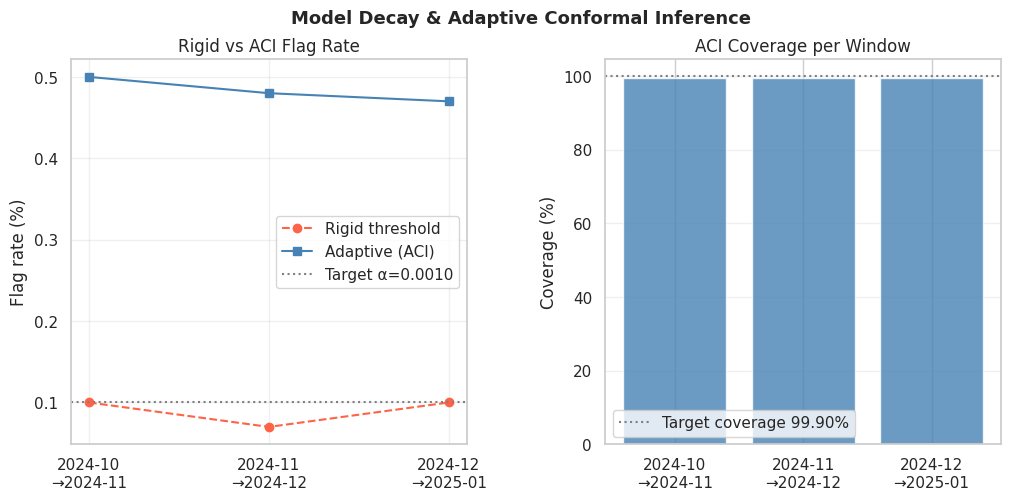

Saved: model_decay.png


In [99]:
# ── Cell 109: Decay plot — rigid vs ACI ──────────────────────────────────────
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

windows = decay_df['window'].tolist()
x = range(len(windows))
labels = [f"{r['cal_month']}\n→{r['test_month']}" for _, r in decay_df.iterrows()]

# 1. Flag rate: rigid vs ACI
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, decay_df['flag_rate_rigid'] * 100, 'o--', color='tomato', label='Rigid threshold')
ax1.plot(x, decay_df['flag_rate_aci'] * 100, 's-', color='steelblue', label='Adaptive (ACI)')
ax1.axhline(ALPHA * 100, color='gray', linestyle=':', label=f'Target α={ALPHA:.4f}')
ax1.set_xticks(list(x)); ax1.set_xticklabels(labels)
ax1.set_ylabel('Flag rate (%)'); ax1.set_title('Rigid vs ACI Flag Rate')
ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. ACI coverage per window
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(list(x), decay_df['aci_coverage'] * 100, color='steelblue', alpha=0.8)
ax2.axhline((1 - ALPHA) * 100, color='gray', linestyle=':', label=f'Target coverage {(1-ALPHA)*100:.2f}%')
ax2.set_xticks(list(x)); ax2.set_xticklabels(labels)
ax2.set_ylabel('Coverage (%)'); ax2.set_title('ACI Coverage per Window')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Decay & Adaptive Conformal Inference', fontsize=13, fontweight='bold')
plt.savefig(CKPT + 'model_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_decay.png')

## Wallet aggregation strategy comparison


In [90]:
def conformal_flags_simple(cal_s, test_s, alpha):
    return (test_s >= np.quantile(cal_s, 1 - alpha)).astype(int)

if hasattr(df_flat, 'group_by'):
    ws_df = (df_flat.group_by('wallet').agg([
        pl.col('combined_tx_score').max().alias('max'),
        pl.col('combined_tx_score').mean().alias('mean'),
        pl.col('combined_tx_score').quantile(0.90).alias('p90'),
    ])).to_pandas().set_index('wallet')
else:
    ws_df = df_flat[['wallet', 'combined_tx_score']].groupby('wallet').agg(
        max=('combined_tx_score', 'max'),
        mean=('combined_tx_score', 'mean'),
        p90=('combined_tx_score', lambda x: x.quantile(0.90)),
    )

val_set = set(val_wallets)
tst_set = set(test_wallets)
agg_flags, agg_scores = {}, {}

for name in ['max', 'mean', 'p90']:
    ws = ws_df[name]
    cal_s = ws[ws.index.isin(val_set)].values
    tst_s = ws[ws.index.isin(tst_set)].values
    if len(cal_s) == 0 or len(tst_s) == 0:
        print(f'WARN: {name} — empty cal or test, skipping')
        continue
    agg_flags[name] = conformal_flags_simple(cal_s, tst_s, ALPHA)
    agg_scores[name] = tst_s

assert agg_flags, 'No valid aggregation scores produced.'

base_fl = agg_flags['max']
base_sc = agg_scores['max']
rows = []
for name, fl in agg_flags.items():
    inter = int(np.sum((fl == 1) & (base_fl == 1)))
    union = int(np.sum((fl == 1) | (base_fl == 1)))
    rows.append({
        'aggregation': name, 'flagged': int(fl.sum()),
        'flag_rate_pct': round(fl.mean() * 100, 2),
        'jaccard_vs_max': round(inter / union if union else 1.0, 4),
        'rank_corr_vs_max': round(float(spearmanr(agg_scores[name], base_sc).statistic), 4),
    })

print('Aggregation comparison:')
print(pd.DataFrame(rows).to_string(index=False))
print('\nJaccard < 0.8 or rank_corr < 0.9 → aggregation choice matters.')


Aggregation comparison:
aggregation  flagged  flag_rate_pct  jaccard_vs_max  rank_corr_vs_max
        max      171           0.10          1.0000            1.0000
       mean      276           0.16          0.1374            0.9989
        p90      140           0.08          0.4136            0.9999

Jaccard < 0.8 or rank_corr < 0.9 → aggregation choice matters.


## Final output


In [100]:
if hasattr(df_flat, 'with_columns'):
    df_flat = df_flat.with_columns([
        pl.Series('if_tx_score', if_tx_score),
        pl.Series('tr_tx_score', tr_cdf_tx),
    ])
else:
    df_flat['if_tx_score'] = if_tx_score
    df_flat['tr_tx_score'] = tr_cdf_tx

test_mask_w = wallet_scores['wallet'].isin(test_wallets)
wallet_scores['eval_phase'] = np.where(test_mask_w, 'Test (Out-of-Sample)', 'Train (In-Sample)')

# Backfill conformal_p for non-test wallets (heuristic only)
nan_mask = wallet_scores['conformal_p'].isna()
if nan_mask.any():
    nan_scores = wallet_scores.loc[nan_mask, 'raw_score'].values
    fill_pvals = np.array([(np.sum(cal_scores >= s) + 1) / (len(cal_scores) + 1) for s in nan_scores])
    wallet_scores.loc[nan_mask, 'conformal_p'] = fill_pvals
    wallet_scores.loc[nan_mask, 'conformal_flag'] = (fill_pvals <= ALPHA).astype(int)

wallet_scores['risk_score'] = -np.log10(np.clip(wallet_scores['conformal_p'], 1e-12, 1.0))
wallet_scores['risk_tier'] = pd.cut(
    wallet_scores['risk_score'],
    bins=[-np.inf, 1, 2, 3, np.inf],
    labels=['low', 'medium', 'high', 'critical'])

print(f'Shape: {wallet_scores.shape}')
print(f'NaN conformal_p: {wallet_scores["conformal_p"].isna().sum()}')
print(wallet_scores['eval_phase'].value_counts())

print('\nTop 20 by raw_score:')
cols = [c for c in ['wallet', 'raw_score', 'if_score', 'tr_score', 'conformal_p',
                     'conformal_flag', 'risk_tier', 'eval_phase', 'n_tx'] if c in wallet_scores.columns]
print(wallet_scores.nlargest(20, 'raw_score')[cols].to_string(index=False))

wallet_scores.to_parquet(CKPT + 'wallet_scores_final.parquet', index=False)
if hasattr(df_flat, 'write_parquet'):
    df_flat.write_parquet(CKPT + 'transactions_scored.parquet')
else:
    df_flat.to_parquet(CKPT + 'transactions_scored.parquet', index=False)
print('Saved: wallet_scores_final.parquet, transactions_scored.parquet')


Shape: (619160, 10)
NaN conformal_p: 0
eval_phase
Train (In-Sample)       446385
Test (Out-of-Sample)    172775
Name: count, dtype: int64

Top 20 by raw_score:
                                      wallet  raw_score  if_score  tr_score  conformal_p  conformal_flag risk_tier           eval_phase  n_tx
7kqYtxNmqo5p3muZGmdwBE3sivsP3wEASwgr9iyxxVMp   0.999543  0.999119  0.999967     0.000500             1.0  critical Test (Out-of-Sample)    36
F81xcZ9wx8iXsAf6GVN1oBfpG449AFiAnwHdiLmyS2iG   0.999231  0.999864  0.998598     0.000500             1.0  critical Test (Out-of-Sample)    22
91k9bnVoE6PpEM2scw5xMEH7Unui6BPoNVQFXNkHq3X5   0.999146  0.998994  0.999299     0.000007             1.0  critical    Train (In-Sample)     6
DHrazPMpZcbyvZ89qhVnhfeUXqEjixTTZdfzyudQT6TH   0.998938  0.999163  0.998712     0.000013             1.0  critical    Train (In-Sample)   266
6iem2SZfu1UPXRpB7akyxUU8sAqGF2TtxxgojiP2fWi8   0.998898  0.999768  0.998028     0.000020             1.0  critical    Train (In-Sa

In [101]:
print(wallet_scores['risk_tier'].value_counts())
print(wallet_scores['conformal_p'].describe())

risk_tier
low         562341
medium       50217
high          5275
critical      1327
Name: count, dtype: int64
count    619160.000000
mean          0.635773
std           0.340391
min           0.000007
25%           0.334065
50%           0.676653
75%           1.000000
max           1.000000
Name: conformal_p, dtype: float64


## External baselines: LOF, One-Class SVM, MLP Autoencoder


## Wallet-level comparison


In [102]:
# Compared to the baseline (IF + Transformer AE) via wallet-level Jaccard
# and rank correlation on the test set.  No labels required.


_wallet_arr = df_flat['wallet'].to_numpy() if hasattr(df_flat['wallet'], 'to_numpy') else np.array(df_flat['wallet'])

print('Fitting LOF ...')
_lof = LocalOutlierFactor(n_neighbors=20, contamination='auto',
                          novelty=True, n_jobs=-1)
_rng_lof = np.random.default_rng(42)
_lof_n = train_mask_tx.sum()
_lof_idx = _rng_lof.choice(_lof_n, size=min(25000, _lof_n), replace=False)
_lof.fit(X_tx_norm[train_mask_tx][_lof_idx])
_lof_raw        = -_lof.decision_function(X_tx_norm)
_lof_train_sort = np.sort(_lof_raw[train_mask_tx])
_lof_score      = np.searchsorted(_lof_train_sort, _lof_raw, side='right') / len(_lof_train_sort)

lof_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'lof_score': _lof_score})
    .groupby('wallet')['lof_score'].max()
)

print('Fitting OCSVM (15 k train sample) ...')
_rng_oc  = np.random.default_rng(42)
_oc_n    = train_mask_tx.sum()
_oc_idx  = _rng_oc.choice(_oc_n, size=min(15000, _oc_n), replace=False)
_ocsvm   = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
_ocsvm.fit(X_tx_norm[train_mask_tx][_oc_idx])
_ocsvm_raw        = -_ocsvm.decision_function(X_tx_norm)
_ocsvm_train_sort = np.sort(_ocsvm_raw[train_mask_tx])
_ocsvm_score      = np.searchsorted(_ocsvm_train_sort, _ocsvm_raw, side='right') / len(_ocsvm_train_sort)

ocsvm_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'ocsvm_score': _ocsvm_score})
    .groupby('wallet')['ocsvm_score'].max()
)

print('Fitting MLP AE ...')
class MlpAE(nn.Module):
    def __init__(self, n_feat, hidden=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(n_feat, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 32),     nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(32, hidden),     nn.ReLU(),
                                 nn.Linear(hidden, n_feat))
    def forward(self, x):
        return self.dec(self.enc(x))

_mlp = MlpAE(X_tx_norm.shape[1]).to(device)
_mlp_opt = torch.optim.Adam(_mlp.parameters(), lr=1e-3)
_mlp_dl  = DataLoader(TensorDataset(torch.from_numpy(X_tx_norm[train_mask_tx])),
                      batch_size=256, shuffle=True)
_mlp.train()
for _ep in range(6):
    _tot = 0
    for (_xb,) in _mlp_dl:
        _xb  = _xb.to(device)
        _l   = nn.functional.huber_loss(_mlp(_xb), _xb)
        _mlp_opt.zero_grad(); _l.backward(); _mlp_opt.step()
        _tot += _l.item()
    print(f'  MLP AE epoch {_ep+1}/6  loss={_tot/len(_mlp_dl):.6f}')

_mlp.eval()
_mlp_err = []
with torch.no_grad():
    for _i in range(0, len(X_tx_norm), 1024):
        _xb = torch.from_numpy(X_tx_norm[_i:_i+1024]).to(device)
        _err = nn.functional.huber_loss(_mlp(_xb), _xb, reduction='none').mean(dim=1).cpu().numpy()
        _mlp_err.append(_err)
_mlp_raw        = np.concatenate(_mlp_err)
_mlp_train_sort = np.sort(_mlp_raw[train_mask_tx])
_mlp_score      = np.searchsorted(_mlp_train_sort, _mlp_raw, side='right') / len(_mlp_train_sort)

mlp_wallet_score = (
    pd.DataFrame({'wallet': _wallet_arr, 'mlp_score': _mlp_score})
    .groupby('wallet')['mlp_score'].max()
)

_comp_ws = pl.from_pandas(wallet_scores[['wallet', 'raw_score']])
for _df_ext in [lof_wallet_score, ocsvm_wallet_score, mlp_wallet_score]:
    _comp_ws = _comp_ws.join(pl.from_pandas(_df_ext.reset_index()), on='wallet', how='left')
_comp_ws = _comp_ws.to_pandas().rename(columns={'raw_score': 'baseline'})

_val_m  = _comp_ws['wallet'].isin(val_wallets).values
_test_m = _comp_ws['wallet'].isin(test_wallets).values

_base_cal  = _comp_ws.loc[_val_m,  'baseline'].values
_base_test = _comp_ws.loc[_test_m, 'baseline'].values
_base_fl   = (_base_test >= np.quantile(_base_cal, 1 - ALPHA)).astype(int)

_ext_rows = []
for _det in ['baseline', 'lof_score', 'ocsvm_score', 'mlp_score']:
    _cal_s  = _comp_ws.loc[_val_m,  _det].fillna(0).values
    _test_s = _comp_ws.loc[_test_m, _det].fillna(0).values
    _fl     = (_test_s >= np.quantile(_cal_s, 1 - ALPHA)).astype(int)
    _inter  = int(np.sum((_fl == 1) & (_base_fl == 1)))
    _union  = int(np.sum((_fl == 1) | (_base_fl == 1)))
    _jac    = _inter / _union if _union > 0 else 1.0
    _rho    = float(spearmanr(_test_s, _base_test).correlation)
    _ext_rows.append({'detector': _det,
                      'flagged': int(_fl.sum()),
                      'flag_rate_pct': round(float(_fl.mean() * 100), 2),
                      'jaccard_vs_baseline': round(_jac, 4),
                      'rank_corr_vs_baseline': round(_rho, 4)})

external_baselines_df = pd.DataFrame(_ext_rows)
print('\nExternal baseline comparison (wallet-level):')
print(external_baselines_df.to_string(index=False))
print('\nInterpretation: high Jaccard/rank-corr with baseline → consistent signal;'
      ' low → detectors disagree on which wallets are anomalous.')


Fitting LOF ...
Fitting OCSVM (15 k train sample) ...
Fitting MLP AE ...
  MLP AE epoch 1/6  loss=0.004259
  MLP AE epoch 2/6  loss=0.000136
  MLP AE epoch 3/6  loss=0.000070
  MLP AE epoch 4/6  loss=0.000040
  MLP AE epoch 5/6  loss=0.000019
  MLP AE epoch 6/6  loss=0.000010

External baseline comparison (wallet-level):
   detector  flagged  flag_rate_pct  jaccard_vs_baseline  rank_corr_vs_baseline
   baseline      171           0.10               1.0000                 1.0000
  lof_score      998           0.58               0.0139                 0.0717
ocsvm_score      181           0.10               0.0602                 0.1758
  mlp_score      168           0.10               0.0463                 0.1761

Interpretation: high Jaccard/rank-corr with baseline → consistent signal; low → detectors disagree on which wallets are anomalous.


## 2. Ablation: component contribution vs baseline


In [103]:
def conformal_flags(cal_scores, test_scores, alpha):
    threshold = np.quantile(cal_scores, 1 - alpha)
    pvals = np.array([
        (np.sum(cal_scores >= s) + 1) / (len(cal_scores) + 1)
        for s in test_scores
    ])
    flags = (pvals <= alpha).astype(int)
    return threshold, pvals, flags

val_mask_w  = wallet_scores['wallet'].isin(val_wallets).values
test_mask_w = wallet_scores['wallet'].isin(test_wallets).values

score_sets = {
    'baseline': wallet_scores['raw_score'].values,
    'if_only': wallet_scores['if_score'].values,
    'tr_only': wallet_scores['tr_score'].values,
}

_, _, baseline_test_flags = conformal_flags(
    score_sets['baseline'][val_mask_w],
    score_sets['baseline'][test_mask_w],
    ALPHA,
)

rows = []
for name, scores in score_sets.items():
    thr, pvals, flags = conformal_flags(scores[val_mask_w], scores[test_mask_w], ALPHA)

    inter = np.sum((flags == 1) & (baseline_test_flags == 1))
    union = np.sum((flags == 1) | (baseline_test_flags == 1))
    jaccard = inter / union if union > 0 else 1.0

    rows.append({
        'run': name,
        'threshold': float(thr),
        'flagged_wallets': int(flags.sum()),
        'flag_rate_pct': float(flags.mean() * 100),
        'jaccard_vs_baseline': float(jaccard),
    })

ablation_results = pd.DataFrame(rows)
base_rate = float(ablation_results.loc[ablation_results['run'] == 'baseline', 'flag_rate_pct'].iloc[0])
ablation_results['delta_rate_vs_baseline'] = ablation_results['flag_rate_pct'] - base_rate

print('Ablation results (wallet-level conformal flags):')
print(ablation_results.sort_values('run').to_string(index=False))

Ablation results (wallet-level conformal flags):
     run  threshold  flagged_wallets  flag_rate_pct  jaccard_vs_baseline  delta_rate_vs_baseline
baseline   0.967294              171       0.098973             1.000000                0.000000
 if_only   0.999906              119       0.068876             0.058394               -0.030097
 tr_only   0.998981              150       0.086818             0.006270               -0.012155


## 3. Sensitivity: stability across hyperparameter ranges


In [ ]:
w_if_grid = [0.30, 0.40, 0.50, 0.60, 0.70]
alpha_grid = [0.005, 0.01, 0.02]

if_all = wallet_scores['if_score'].values
tr_all = wallet_scores['tr_score'].values

baseline_test_scores = score_sets['baseline'][test_mask_w]

sens_rows = []

for w_if in w_if_grid:
    w_tr = 1.0 - w_if
    mixed_scores = w_if * if_all + w_tr * tr_all

    for alpha in alpha_grid:
        _, _, flags = conformal_flags(mixed_scores[val_mask_w], mixed_scores[test_mask_w], alpha)

        inter = np.sum((flags == 1) & (baseline_test_flags == 1))
        union = np.sum((flags == 1) | (baseline_test_flags == 1))
        jaccard = inter / union if union > 0 else 1.0

        rho = spearmanr(mixed_scores[test_mask_w], baseline_test_scores).correlation
        if np.isnan(rho):
            rho = 0.0

        sens_rows.append({
            'w_if': float(w_if),
            'w_tr': float(w_tr),
            'alpha': float(alpha),
            'flag_rate_pct': float(flags.mean() * 100),
            'jaccard_vs_baseline': float(jaccard),
            'rank_corr_vs_baseline': float(rho),
        })

sensitivity_results = pd.DataFrame(sens_rows)
print('Sensitivity sweep:')
print(sensitivity_results.sort_values(['alpha', 'w_if']).to_string(index=False))

## 4. Contamination: baseline detection on synthetic anomalies


In [ ]:
_ckpt    = torch.load('/workspace/checkpoints/ae_model.pt', map_location=device)
_cfg     = _ckpt['cfg']
_cfg_keys = TxTransformerAE.__init__.__code__.co_varnames

tr_model = TxTransformerAE(
  n_features=X_tx.shape[1],
  **{k: v for k, v in _cfg.items() if k in _cfg_keys and k != 'n_features'}
)
tr_model.load_state_dict(_ckpt['state_dict'])
tr_model = tr_model.to(device).eval()

iforest = joblib.load('/workspace/checkpoints/iforest.pkl')
print('Models reloaded.')

rng = np.random.default_rng(42)
feat_idx = {f: i for i, f in enumerate(tx_feature_cols)}

normal_pool = np.where(test_mask_tx & (combined_tx <= np.quantile(combined_tx[test_mask_tx], 0.50)))[0]
if len(normal_pool) == 0:
    normal_pool = np.where(test_mask_tx)[0]

n_syn = int(min(5000, len(normal_pool)))
if n_syn == 0:
    raise RuntimeError('No test transactions available for contamination analysis.')
syn_pick = rng.choice(normal_pool, size=n_syn, replace=False)
X_syn_raw = X_tx[syn_pick].copy()

# Inject synthetic anomalous patterns
for f in ['fee_sol', 'compute_units_consumed', 'fanout_ratio', 'cpi_ratio', 'drain_sol_ratio', 'inner_instructions']:
    if f in feat_idx:
        j = feat_idx[f]
        X_syn_raw[:, j] = X_syn_raw[:, j] * rng.uniform(2.5, 6.0, size=n_syn)

if 'success_flag' in feat_idx:
    X_syn_raw[:, feat_idx['success_flag']] = 0.0

train_std = X_tx[train_mask_tx].std(axis=0) + 1e-6
X_syn_raw += rng.normal(0.0, 1.25 * train_std, size=X_syn_raw.shape)

# Re-score synthetic tx with trained baseline components
if_syn_raw = -iforest.decision_function(X_syn_raw)
# Training-CDF normalisation: reuse sorted training arrays from cells 9/14.
if_syn = np.searchsorted(_if_train_sort, if_syn_raw, side='right') / len(_if_train_sort)

X_syn_norm = scaler.transform(X_syn_raw).astype(np.float32)
tr_syn_raw, _ = score_tx_ae(tr_model, X_syn_norm, device)
tr_syn = np.searchsorted(_tr_train_sort, tr_syn_raw, side='right') / len(_tr_train_sort)

combined_syn = np.maximum(if_syn, tr_syn)

if_thr = np.quantile(if_tx_score[val_mask_tx], 1 - ALPHA)
tr_thr = np.quantile(tr_tx_score[val_mask_tx], 1 - ALPHA)
comb_thr = np.quantile(combined_tx[val_mask_tx], 1 - ALPHA)

contamination_results = pd.DataFrame([
    {'detector': 'if_only', 'threshold': float(if_thr), 'synthetic_detection_rate_pct': float((if_syn >= if_thr).mean() * 100)},
    {'detector': 'tr_only', 'threshold': float(tr_thr), 'synthetic_detection_rate_pct': float((tr_syn >= tr_thr).mean() * 100)},
    {'detector': 'baseline_combined', 'threshold': float(comb_thr), 'synthetic_detection_rate_pct': float((combined_syn >= comb_thr).mean() * 100)},
])

print('Synthetic contamination detection rates:')
print(contamination_results.to_string(index=False))

# Heatmap: archetype × detector

_heat = archetype_detection_df.set_index('archetype')[['IF %', 'TR %', 'Combined %']]
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(_heat, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.5, ax=ax)
ax.set_title(f'Synthetic Detection Rate (%) by Archetype & Detector\n'
             f'(injection multiplier={INJECT_MULTIPLIER}x, n={n_syn} per archetype)')
ax.set_xlabel('Detector')
ax.set_ylabel('Injected Archetype')
plt.tight_layout()
plt.savefig('archetype_detection_rates.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: archetype_detection_rates.png')

## Heatmap: flagged wallets × top features


In [ ]:
# For each flagged test wallet:

if 'per_feat_errors' not in globals():
  per_feat_errors = np.load('/workspace/checkpoints/per_feat_errors.npy')

flagged = wallet_scores[
  wallet_scores['wallet'].isin(test_wallets) &
  (wallet_scores['conformal_flag'].fillna(0).astype(int) == 1)
].sort_values('raw_score', ascending=False).head(20).copy()

if len(flagged) == 0:
  print('No flagged test wallets at current alpha.')
else:
  # Top transaction per flagged wallet (highest AE error)
  _tr_col = 'tr_tx_score' if 'tr_tx_score' in df_flat.columns else 'if_tx_score'
  tx_top_idx = df_flat.groupby('wallet')[_tr_col].idxmax()

  feat_matrix = []
  labels = []
  rows = []

  for _, row in flagged.iterrows():
      w = row['wallet']
      tx_idx = tx_top_idx.get(w)
      if tx_idx is None:
          continue

      feat_err = per_feat_errors[int(tx_idx)]
      topk_idx = np.argsort(feat_err)[-5:][::-1]
      dominant = 'IF' if row['if_score'] >= row['tr_score'] else 'AE'

      feat_matrix.append(feat_err)
      labels.append(f"{w[:8]}… [{dominant}] p={row['conformal_p']:.3f}")
      rows.append({
          'wallet':      w[:12] + '…',
          'raw_score':   round(float(row['raw_score']), 4),
          'if_score':    round(float(row['if_score']),  4),
          'tr_score':    round(float(row['tr_score']),  4),
          'conformal_p': round(float(row['conformal_p']), 4) if pd.notna(row['conformal_p']) else np.nan,
          'dominant':    dominant,
          'top_features': ', '.join(tx_feature_cols[i] for i in topk_idx),
      })

  print(pd.DataFrame(rows).to_string(index=False))

  feat_mat = np.array(feat_matrix)                         # (n_wallets, n_features)
  top_feat_idx = np.argsort(feat_mat.mean(axis=0))[-15:]  # top 15 features by mean error
  feat_mat_top = feat_mat[:, top_feat_idx]
  feat_names_top = [tx_feature_cols[i] for i in top_feat_idx]

  fig, ax = plt.subplots(figsize=(14, max(4, len(labels) * 0.5)))
  sns.heatmap(feat_mat_top, annot=False, cmap='YlOrRd',
              xticklabels=feat_names_top, yticklabels=labels,
              linewidths=0.3, ax=ax)
  ax.set_title('AE Reconstruction Error by Feature — Top Flagged Wallets', fontweight='bold')
  ax.set_xlabel('Feature'); ax.set_ylabel('Wallet [dominant detector] [conformal p]')
  ax.tick_params(axis='x', rotation=45)
  plt.tight_layout()
  plt.savefig('/workspace/checkpoints/interpretability_heatmap.png', dpi=150, bbox_inches='tight')
  plt.show()
  print('Saved: interpretability_heatmap.png')

## SHAP interpretability (Isolation Forest component)


In [ ]:
# Addresses the black-box concern by explaining which features drive IF anomaly
# scores for top anomalous test transactions.

shap_global_df = pd.DataFrame()
shap_local_top_df = pd.DataFrame()

try:
    import shap
except Exception:
    print('SHAP is not installed in this environment. Run `pip install shap` and re-run this cell.')
else:
    required_vars = ['iforest', 'if_tx_score', 'X_tx', 'test_mask_tx', 'tx_feature_cols', 'df_flat']
    missing_vars = [v for v in required_vars if v not in globals()]
    if missing_vars:
        raise RuntimeError(f'Missing prerequisites for SHAP: {missing_vars}')

    bg_n = int(min(2000, np.sum(train_mask_tx))) if 'train_mask_tx' in globals() else int(min(2000, len(X_tx)))
    ex_n = int(min(300, np.sum(test_mask_tx)))
    if ex_n <= 0:
        raise RuntimeError('No test transactions available for SHAP interpretation.')

    rng_shap = np.random.default_rng(42)
    if 'train_mask_tx' in globals() and np.sum(train_mask_tx) > 0:
        train_idx = np.where(train_mask_tx)[0]
    else:
        train_idx = np.arange(len(X_tx))
    bg_idx = rng_shap.choice(train_idx, size=bg_n, replace=False) if len(train_idx) > bg_n else train_idx
    X_bg = X_tx[bg_idx].astype(np.float32)
    X_ex = X_tx[explain_idx].astype(np.float32)

    shap_values = None
    shap_mode = 'tree'

    try:
        explainer = shap.TreeExplainer(iforest)
        shap_values = explainer.shap_values(X_ex)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        shap_values = np.asarray(shap_values, dtype=float)
    except Exception:
        shap_mode = 'model_agnostic'

        def _if_anom(x):
            x = np.asarray(x, dtype=np.float32)
            return -iforest.decision_function(x)

        explainer = shap.Explainer(_if_anom, X_bg, feature_names=tx_feature_cols)
        shap_out = explainer(X_ex)
        shap_values = np.asarray(shap_out.values, dtype=float)

    if shap_values.ndim != 2 or shap_values.shape[1] != len(tx_feature_cols):
        raise RuntimeError(f'Unexpected SHAP output shape: {shap_values.shape}')

    # Global IF feature importance
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    shap_global_df = (
        pd.DataFrame({'feature': tx_feature_cols, 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    print(f'SHAP mode: {shap_mode}')
    print('Top IF feature drivers by mean |SHAP|:')
    print(shap_global_df.head(15).to_string(index=False))

    # Local explanations for top anomalous transactions
    top_feat = shap_global_df.head(12)['feature'].tolist()
    top_feat_idx = [tx_feature_cols.index(f) for f in top_feat]

    shap_local_top_df = pd.DataFrame(
        shap_values[:, top_feat_idx],
        columns=top_feat,
    )
    shap_local_top_df['tx_idx'] = explain_idx
    shap_local_top_df['wallet'] = df_flat.iloc[explain_idx]['wallet'].astype(str).values
    shap_local_top_df['if_score'] = if_tx_score[explain_idx]

    # Seaborn visualisations
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    sns.barplot(data=shap_global_df.head(15), x='mean_abs_shap', y='feature', color='#4C78A8', ax=axes[0])
    axes[0].set_title('SHAP global importance (Isolation Forest)')
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_ylabel('Feature')

    hm_n = int(min(20, len(shap_local_top_df)))
    hm = shap_local_top_df[top_feat].head(hm_n).to_numpy(dtype=float)
    row_labels = []
    for w in shap_local_top_df['wallet'].head(hm_n):
        ws = str(w)
        row_labels.append(ws if len(ws) <= 14 else f'{ws[:6]}...{ws[-4:]}')

    sns.heatmap(
        hm,
        cmap='coolwarm',
        center=0.0,
        xticklabels=top_feat,
        yticklabels=row_labels,
        cbar_kws={'label': 'SHAP value'},
        ax=axes[1],
    )
    axes[1].set_title('Local SHAP (top anomalous test transactions)')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Transaction (wallet)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    if 'no_label_dashboard' in globals():
        no_label_dashboard['if_shap_global'] = shap_global_df
        no_label_dashboard['if_shap_local_top'] = shap_local_top_df

print('Saved SHAP outputs: `shap_global_df`, `shap_local_top_df` (and dashboard keys if available).')

## Seaborn heatmap


In [ ]:
def _clean(x):
  x = np.asarray(x, dtype=float)
  return x[np.isfinite(x)]

def _drift_ks(ref, cur):
  r, c = _clean(ref), _clean(cur)
  if len(r) == 0 or len(c) == 0: return np.nan
  return float(ks_2samp(r, c).statistic)

_val_m  = wallet_scores['wallet'].isin(val_wallets).values
_test_m = wallet_scores['wallet'].isin(test_wallets).values

model_score_map = {
  'baseline': wallet_scores['raw_score'].to_numpy(dtype=float),
  'if_only':  wallet_scores['if_score'].to_numpy(dtype=float),
  'tr_only':  wallet_scores['tr_score'].to_numpy(dtype=float),
}
if '_comp_ws' in globals() and isinstance(_comp_ws, pd.DataFrame):
  for col in ['lof_score', 'ocsvm_score', 'mlp_score']:
      if col in _comp_ws.columns:
          model_score_map[col.replace('_score', '')] = (
              _comp_ws[['wallet', col]].drop_duplicates('wallet')
              .set_index('wallet').reindex(wallet_scores['wallet'])
              [col].fillna(0.0).to_numpy(dtype=float)
          )

_base_val  = _clean(model_score_map['baseline'][_val_m])
_base_test = _clean(model_score_map['baseline'][_test_m])
_base_thr  = float(np.quantile(_base_val, 1 - ALPHA))
_base_fl   = (_base_test >= _base_thr).astype(int)

rows = []
for det, arr in model_score_map.items():
  vs = _clean(arr[_val_m]); ts = _clean(arr[_test_m])
  if not len(vs) or not len(ts): continue
  thr = float(np.quantile(vs, 1 - ALPHA))
  fl  = (ts >= thr).astype(int)
  inter = int(np.sum((fl == 1) & (_base_fl == 1)))
  union = int(np.sum((fl == 1) | (_base_fl == 1)))
  rows.append({
      'detector':        det,
      'flag_rate_%':     round(fl.mean() * 100, 2),
      'tail_contrast':   round(float(np.quantile(ts, 0.99) - np.quantile(ts, 0.50)), 4),
      'jaccard_base':    round(inter / union, 4) if union else 1.0,
      'rank_corr_base':  round(float(spearmanr(ts, _base_test).correlation), 4),
      'ks_val_test':     round(_drift_ks(vs, ts), 4),
  })

model_error_metrics = pd.DataFrame(rows)
_ord = {'baseline': 0, 'if_only': 1, 'tr_only': 2, 'lof': 3, 'ocsvm': 4, 'mlp': 5}
model_error_metrics = model_error_metrics.iloc[
  model_error_metrics['detector'].map(_ord).fillna(99).argsort()
].reset_index(drop=True)


_plot = model_error_metrics.set_index('detector')
_norm = (_plot - _plot.min()) / (_plot.max() - _plot.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, max(3, len(_plot) * 0.7)))
sns.heatmap(
  _norm, annot=_plot.round(3), fmt='g',
  cmap='RdYlGn_r', linewidths=0.5, linecolor='white',
  cbar_kws={'label': 'Normalised (0=best, 1=worst)'},
  ax=ax,
)
ax.set_title('Model Error Metrics — No-Label Evaluation', fontsize=13, fontweight='bold')
ax.set_ylabel(''); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/workspace/checkpoints/model_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(model_error_metrics.to_string(index=False))

## Summary table


In [ ]:
# Covers: CP validity + p-value sharpness | AE HUB | IF separation | Jaccard stability
# MV/EM curves replaced by tail_contrast + Wasserstein (equivalent, no re-fits needed).


eval_rows = []

# Guarantee: realized false-alarm rate ≤ α on held-out normal (val) wallets.
_cp_val  = wallet_scores.loc[wallet_scores['wallet'].isin(val_wallets),  'conformal_p'].dropna().values
_cp_test = wallet_scores.loc[wallet_scores['wallet'].isin(test_wallets), 'conformal_p'].dropna().values

print('── CP Empirical Validity (realized false-alarm rate vs target α) ──')
print(f'  {"α_target":>10} {"α_realized":>12} {"gap_pp":>10} {"valid?":>8}')
for a in [0.005, 0.01, 0.02, 0.05]:
  realized = float(np.mean(_cp_val <= a)) if len(_cp_val) else np.nan
  gap = abs(realized - a) * 100 if np.isfinite(realized) else np.nan
  valid = '✓' if np.isfinite(gap) and gap < 1.0 else '✗'
  print(f'  {a:>10.3f} {realized:>12.4f} {gap:>9.2f}% {valid:>8}')
  eval_rows.append({'metric': f'CP_validity_alpha={a}', 'value': round(realized, 4) if np.isfinite(realized) else np.nan})

if len(_cp_test) > 0:
  _hist, _ = np.histogram(_cp_test, bins=20, range=(0, 1), density=True)
  _hist = np.clip(_hist, 1e-9, None)
  _pval_entropy = float(scipy_entropy(_hist / _hist.sum()))
  _pval_low = float(np.mean(_cp_test < ALPHA))
  print(f'\n── P-value sharpness ──')
  print(f'  p-value entropy (lower=sharper): {_pval_entropy:.4f}')
  print(f'  fraction with p < α={ALPHA}:     {_pval_low:.4f}')
  eval_rows.append({'metric': 'pval_entropy',           'value': round(_pval_entropy, 4)})
  eval_rows.append({'metric': 'pval_flagged_at_alpha',  'value': round(_pval_low, 4)})

if 'tr_raw' in globals():
  _test_tx_mask = df_flat['wallet'].isin(test_wallets).values
  _ae_mse_test  = float(np.mean(tr_raw[_test_tx_mask] ** 2))
  _ae_mse_train = float(np.mean(tr_raw[train_mask_tx] ** 2))
  _ae_ratio     = _ae_mse_test / max(_ae_mse_train, 1e-12)
  print(f'\n── AE Reconstruction MSE ──')
  print(f'  Train MSE : {_ae_mse_train:.6f}')
  print(f'  Test  MSE : {_ae_mse_test:.6f}')
  print(f'  Test/Train ratio (≈1 = no overfit): {_ae_ratio:.4f}')
  eval_rows.append({'metric': 'ae_mse_train',      'value': round(_ae_mse_train, 6)})
  eval_rows.append({'metric': 'ae_mse_test',       'value': round(_ae_mse_test,  6)})
  eval_rows.append({'metric': 'ae_mse_test/train', 'value': round(_ae_ratio,     4)})
else:
  print('\nAE MSE skipped: tr_raw not in scope (run AE scoring cell first).')

if 'model_error_metrics' in globals() and len(model_error_metrics):
  _base_row = model_error_metrics[model_error_metrics['detector'] == 'baseline']
  if len(_base_row):
      _tc = float(_base_row['tail_contrast'].values[0])
      _ks = float(_base_row['ks_val_test'].values[0])
      print(f'\n── IF Score Separation (MV/EM proxy) ──')
      print(f'  Tail contrast  (p99-p50) : {_tc:.4f}  [higher = better separation]')
      print(f'  KS stat val→test         : {_ks:.4f}  [lower = more stable]')
      eval_rows.append({'metric': 'if_tail_contrast', 'value': round(_tc, 4)})
      eval_rows.append({'metric': 'if_ks_val_test',   'value': round(_ks, 4)})

if 'struct_perm_df' in globals() and len(struct_perm_df):
  _jac_mean = float(struct_perm_df['jaccard_vs_original_flags'].mean())
  _jac_std  = float(struct_perm_df['jaccard_vs_original_flags'].std())
  print(f'\n── Jaccard Subsample Stability ──')
  print(f'  Mean Jaccard : {_jac_mean:.4f} ± {_jac_std:.4f}')
  print(f'  n_runs       : {len(struct_perm_df)}')
  eval_rows.append({'metric': 'jaccard_stability_mean', 'value': round(_jac_mean, 4)})
  eval_rows.append({'metric': 'jaccard_stability_std',  'value': round(_jac_std,  4)})
else:
  print('\nJaccard stability skipped: run permutation cell first.')

eval_summary = pd.DataFrame(eval_rows)
print('\n── Evaluation Summary ──')
print(eval_summary.to_string(index=False))


## 8. Export monitoring artifacts (CSV + PNG)


In [ ]:
if 'no_label_dashboard' not in globals():
    raise RuntimeError('Run section 6 (No-label evaluation dashboard) first.')
if 'render_no_label_dashboard' not in globals():
    raise RuntimeError('Run section 7 first (dashboard renderer missing).')

EXPORT_ROOT = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()
OUT_DIR = os.path.join(EXPORT_ROOT, 'monitoring')
os.makedirs(OUT_DIR, exist_ok=True)

export_rows = []

# 1) Export dashboard tables
for name, obj in no_label_dashboard.items():
    if isinstance(obj, pd.DataFrame):
        out_path = os.path.join(OUT_DIR, f'{name}.csv')
        obj.to_csv(out_path, index=(name == 'agreement_corr'))
        export_rows.append({'artifact': name, 'type': 'csv', 'path': out_path, 'rows': int(len(obj))})

# 2) Render one compact dashboard figure via shared renderer
fig_path = os.path.join(OUT_DIR, 'no_label_dashboard.png')
_ = render_no_label_dashboard(no_label_dashboard, save_path=fig_path, show=False)
export_rows.append({'artifact': 'no_label_dashboard', 'type': 'png', 'path': fig_path, 'rows': np.nan})

# 3) Save manifest
manifest = pd.DataFrame(export_rows)
manifest_path = os.path.join(OUT_DIR, 'monitoring_manifest.csv')
manifest.to_csv(manifest_path, index=False)

print('Export complete. Artifacts:')
print(manifest.to_string(index=False))
print(f'\nOutput folder: {OUT_DIR}')

In [ ]:
# Fig 1: Score separation (hist + KDE)
# Fig 2: Detector agreement scatter
# Fig 3: Conformal calibration curve
# Fig 4: Temporal monitoring trend


MAIN_FIG_DIR = '/workspace/checkpoints/main_figures/'
os.makedirs(MAIN_FIG_DIR, exist_ok=True)

alpha_main   = float(ALPHA) if 'ALPHA' in globals() else 0.01
test_mask_m  = wallet_scores['wallet'].isin(test_wallets).values
val_mask_m   = wallet_scores['wallet'].isin(val_wallets).values
flag_m       = wallet_scores['conformal_flag'].fillna(0).astype(int).to_numpy()
n_tx_m       = wallet_scores['n_tx'].fillna(1).to_numpy(dtype=float) if 'n_tx' in wallet_scores.columns else np.ones(len(wallet_scores))

def _fin(a): return np.asarray(a, dtype=float)[np.isfinite(np.asarray(a, dtype=float))]

def _hist_kde(ax, data, color, label, alpha=0.35):
  x = _fin(data)
  if not len(x): return
  sns.histplot(x=x, bins=45, stat='density', alpha=alpha, color=color, label=f'{label} hist', ax=ax)
  if len(np.unique(x)) > 3:
      try: sns.kdeplot(x=x, color=color, linewidth=2.0, label=f'{label} KDE', ax=ax)
      except: pass

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=False)
for ax, (col, title) in zip(axes, [
  ('if_score',  'Isolation Forest score'),
  ('tr_score',  'Transformer AE score'),
  ('raw_score', 'Combined score'),
]):
  val_x = _fin(wallet_scores.loc[val_mask_m,  col].to_numpy(dtype=float))
  tst_x = _fin(wallet_scores.loc[test_mask_m, col].to_numpy(dtype=float))
  _hist_kde(ax, val_x, '#4C78A8', 'Val')
  _hist_kde(ax, tst_x, '#F58518', 'Test')
  if len(val_x):
      ax.axvline(np.quantile(val_x, 1 - alpha_main), linestyle='--', linewidth=1.6,
                 color='black', label=f'Threshold α={alpha_main:.3f}')
  ax.set_title(title); ax.set_xlabel(col); ax.grid(alpha=0.2)
axes[0].set_ylabel('Density')
axes[-1].legend(loc='best', fontsize=8)
fig.suptitle('Score separation: validation vs test', y=1.02)
plt.tight_layout()
fig.savefig(MAIN_FIG_DIR + '01_score_separation.png', dpi=170, bbox_inches='tight')
plt.show()
print('Saved: 01_score_separation.png')

plot_df = wallet_scores.loc[test_mask_m, ['wallet', 'if_score', 'tr_score']].copy()
plot_df['flag']        = flag_m[test_mask_m]
plot_df['flag_label']  = np.where(plot_df['flag'] == 1, 'Flagged', 'Unflagged')
plot_df['size_scaled'] = 20 + 90 * (np.log1p(n_tx_m[test_mask_m]) / np.log1p(max(n_tx_m.max(), 1)))

fig, ax = plt.subplots(figsize=(7.6, 6.2))
sns.scatterplot(data=plot_df, x='if_score', y='tr_score', hue='flag_label',
              size='size_scaled', sizes=(20, 110), alpha=0.70, ax=ax)
thr_if = float(np.quantile(_fin(wallet_scores.loc[val_mask_m, 'if_score']), 1 - alpha_main))
thr_tr = float(np.quantile(_fin(wallet_scores.loc[val_mask_m, 'tr_score']), 1 - alpha_main))
ax.axvline(thr_if, linestyle='--', linewidth=1.2, color='gray')
ax.axhline(thr_tr, linestyle='--', linewidth=1.2, color='gray')
ax.set_title('Detector agreement map (test wallets)')
ax.set_xlabel('IF score'); ax.set_ylabel('AE score'); ax.legend(loc='best')
plt.tight_layout()
fig.savefig(MAIN_FIG_DIR + '02_detector_agreement.png', dpi=170, bbox_inches='tight')
plt.show()
print('Saved: 02_detector_agreement.png')

cal = _fin(wallet_scores.loc[val_mask_m,  'raw_score'].to_numpy(dtype=float))
tst = _fin(wallet_scores.loc[test_mask_m, 'raw_score'].to_numpy(dtype=float))
conf_rows = []
for a in [0.005, 0.01, 0.02, 0.05]:
  thr  = float(np.quantile(cal, 1 - a)) if len(cal) else np.nan
  rate = float((tst >= thr).mean() * 100) if len(tst) and np.isfinite(thr) else np.nan
  conf_rows.append({'target_pct': a * 100, 'realized_pct': rate})
conf_df = pd.DataFrame(conf_rows)

fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.lineplot(data=conf_df, x='target_pct', y='realized_pct', marker='o', linewidth=2.0, label='Realised', ax=ax)
_x = conf_df['target_pct'].to_numpy(dtype=float)
sns.lineplot(x=_x, y=_x, linestyle='--', linewidth=1.3, color='black', label='Ideal y=x', ax=ax)
ax.set_title('Conformal calibration (wallet-level)')
ax.set_xlabel('Target alpha (%)'); ax.set_ylabel('Realised flag rate (%)'); ax.legend()
plt.tight_layout()
fig.savefig(MAIN_FIG_DIR + '03_conformal_calibration.png', dpi=170, bbox_inches='tight')
plt.show()
print('Saved: 03_conformal_calibration.png')

_ts_col = 'tr_tx_score' if 'tr_tx_score' in df_flat.columns else 'if_tx_score'
wallet_ts = (
  df_flat.loc[df_flat.groupby('wallet')[_ts_col].idxmax(), ['wallet', 'block_timestamp']]
  .drop_duplicates('wallet').set_index('wallet')['block_timestamp']
)
trend = wallet_scores.loc[test_mask_m, ['wallet', 'raw_score']].copy()
trend['flag']      = flag_m[test_mask_m]
trend['top_tx_ts'] = pd.to_datetime(trend['wallet'].map(wallet_ts), errors='coerce')
trend = trend.dropna(subset=['top_tx_ts'])

if len(trend):
  trend['week'] = trend['top_tx_ts'].dt.to_period('W').dt.start_time
  wf  = trend.groupby('week')['flag'].sum().sort_index()
  wrs = trend.groupby('week')['raw_score'].median().rolling(4, min_periods=1).mean().sort_index()

  fig, ax1 = plt.subplots(figsize=(10.2, 5.0))
  sns.lineplot(x=wf.index, y=wf.values, marker='o', linewidth=1.8, label='Flagged wallets/week', ax=ax1)
  ax1.set_xlabel('Week'); ax1.set_ylabel('Flagged wallets')
  ax2 = ax1.twinx()
  sns.lineplot(x=wrs.index, y=wrs.values, marker='s', linewidth=2.0,
               color='#E45756', label='Rolling median raw score (4w)', ax=ax2)
  ax2.set_ylabel('Raw score (median)')
  l1, lb1 = ax1.get_legend_handles_labels()
  l2, lb2 = ax2.get_legend_handles_labels()
  ax1.legend(l1 + l2, lb1 + lb2, loc='upper left')
  ax1.set_title('Temporal monitoring: weekly flagged volume and score trend')
  ax1.get_legend().remove() if ax1.get_legend() else None
  plt.tight_layout()
  fig.savefig(MAIN_FIG_DIR + '04_temporal_trend.png', dpi=170, bbox_inches='tight')
  plt.show()
  print('Saved: 04_temporal_trend.png')
else:
  print('Fig 4 skipped: no timestamp data available.')

print(f'\nAll figures saved to {MAIN_FIG_DIR}')

## 12. Appendix visual pack (robustness + ops diagnostics)


In [ ]:
APP_FIG_DIR = '/workspace/monitoring/appendix_figures'
os.makedirs(APP_FIG_DIR, exist_ok=True)
appendix_manifest = []


def _finite_local(a):
  x = np.asarray(a, dtype=float)
  return x[np.isfinite(x)]


def _psi_month(expected, actual, bins=10, eps=1e-6):
  exp = _finite_local(expected)
  act = _finite_local(actual)
  if len(exp) == 0 or len(act) == 0:
      return np.nan
  edges = np.quantile(exp, np.linspace(0, 1, bins + 1))
  edges = np.unique(edges)
  if len(edges) < 3:
      return 0.0
  exp_hist, _ = np.histogram(exp, bins=edges)
  act_hist, _ = np.histogram(act, bins=edges)
  exp_pct = np.clip(exp_hist / max(exp_hist.sum(), 1), eps, None)
  act_pct = np.clip(act_hist / max(act_hist.sum(), 1), eps, None)
  return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def _wallet_time_map_appendix(df):
  if {'wallet', 'block_timestamp', 'combined_tx_score'}.issubset(df.columns):
      idx = df.groupby('wallet')['combined_tx_score'].idxmax()
  elif {'wallet', 'block_timestamp', 'tr_tx_score'}.issubset(df.columns):
      idx = df.groupby('wallet')['tr_tx_score'].idxmax()
  elif {'wallet', 'block_timestamp'}.issubset(df.columns):
      idx = df.groupby('wallet')['block_timestamp'].idxmax()
  else:
      return pd.Series(dtype='datetime64[ns]')
  out = (
      df.loc[idx, ['wallet', 'block_timestamp']]
      .drop_duplicates('wallet')
      .set_index('wallet')['block_timestamp']
  )
  return pd.to_datetime(out, errors='coerce')


# A1) Hyperparameter heatmaps (from section 3 sensitivity sweep)
if 'sensitivity_results' in globals() and isinstance(sensitivity_results, pd.DataFrame) and len(sensitivity_results):
  piv_flag = sensitivity_results.pivot(index='alpha', columns='w_if', values='flag_rate_pct').sort_index()
  piv_jac = sensitivity_results.pivot(index='alpha', columns='w_if', values='jaccard_vs_baseline').sort_index()

  fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
  sns.heatmap(piv_flag, cmap='viridis', annot=True, fmt='.2f', cbar_kws={'label': 'Flag rate (%)'}, ax=axes[0])
  axes[0].set_title('Flag rate (%)')
  axes[0].set_xlabel('w_if'); axes[0].set_ylabel('alpha')

  sns.heatmap(piv_jac, cmap='magma', annot=True, fmt='.3f', cbar_kws={'label': 'Jaccard'}, ax=axes[1])
  axes[1].set_title('Jaccard vs baseline')
  axes[1].set_xlabel('w_if'); axes[1].set_ylabel('alpha')

  plt.tight_layout()
  a1_path = os.path.join(APP_FIG_DIR, 'A1_hyperparameter_heatmaps.png')
  fig.savefig(a1_path, dpi=170, bbox_inches='tight')
  plt.show()
  appendix_manifest.append({'figure': 'A1_hyperparameter_heatmaps', 'path': a1_path})
else:
  print('A1 skipped: sensitivity_results not found.')


# A2) IF contamination sweep curves (from section 9)
if 'if_sensitivity_results' in globals() and isinstance(if_sensitivity_results, pd.DataFrame) and len(if_sensitivity_results):
  d = if_sensitivity_results.sort_values('contamination').copy()
  d['jaccard_vs_ref_pct'] = 100.0 * d['jaccard_vs_ref'] if 'jaccard_vs_ref' in d.columns else np.nan
  d['rank_corr_vs_ref_pct'] = 100.0 * d['rank_corr_vs_ref'] if 'rank_corr_vs_ref' in d.columns else np.nan

  pcols = [c for c in ['flag_rate_pct', 'jaccard_vs_ref_pct', 'rank_corr_vs_ref_pct'] if c in d.columns]
  dm = d.melt(id_vars='contamination', value_vars=pcols, var_name='metric', value_name='percent')

  fig, ax = plt.subplots(figsize=(8.6, 5.0))
  sns.lineplot(data=dm, x='contamination', y='percent', hue='metric', marker='o', ax=ax)
  ax.set_xscale('log')
  ax.set_title('A2. IF contamination sensitivity')
  ax.set_xlabel('contamination'); ax.set_ylabel('Percent')
  ax.legend(loc='best')

  plt.tight_layout()
  a2_path = os.path.join(APP_FIG_DIR, 'A2_if_contamination_sensitivity.png')
  fig.savefig(a2_path, dpi=170, bbox_inches='tight')
  plt.show()
  appendix_manifest.append({'figure': 'A2_if_contamination_sensitivity', 'path': a2_path})
else:
  print('A2 skipped: if_sensitivity_results not found.')


# A4) Rolling drift panel by month (raw_score)
monthly_drift = pd.DataFrame()
if 'wallet_scores' in globals() and 'df_flat' in globals() and 'raw_score' in wallet_scores.columns:
  tmap = _wallet_time_map_appendix(df_flat)
  wd = wallet_scores[['wallet', 'raw_score']].copy()
  if 'test_wallets' in globals():
      wd = wd[wd['wallet'].isin(test_wallets)]
  wd['ts'] = pd.to_datetime(wd['wallet'].map(tmap), errors='coerce')
  wd = wd.dropna(subset=['ts'])

  if len(wd):
      wd['month'] = wd['ts'].dt.to_period('M').dt.to_timestamp()
      months = sorted(wd['month'].dropna().unique())

      rows = []
      prev = None
      for m in months:
          cur = _finite_local(wd.loc[wd['month'] == m, 'raw_score'].to_numpy(dtype=float))
          if prev is None:
              prev = cur; continue
          if len(prev) == 0 or len(cur) == 0:
              prev = cur; continue
          ks_stat, ks_p = ks_2samp(prev, cur)
          rows.append({
              'month': pd.Timestamp(m),
              'ks_stat': float(ks_stat),
              'ks_pvalue': float(ks_p),
              'wasserstein': float(wasserstein_distance(prev, cur)),
              'psi': float(_psi_month(prev, cur, bins=10)),
          })
          prev = cur

      monthly_drift = pd.DataFrame(rows)

      if len(monthly_drift):
          mdm = monthly_drift.melt(id_vars='month', value_vars=['ks_stat', 'wasserstein', 'psi'], var_name='metric', value_name='value')
          fig, ax = plt.subplots(figsize=(10.2, 4.8))
          sns.lineplot(data=mdm, x='month', y='value', hue='metric', marker='o', ax=ax)
          ax.set_title('A4. Rolling monthly drift (raw_score, month-to-month)')
          ax.set_xlabel('Month'); ax.set_ylabel('Drift metric value')
          ax.legend(loc='best')

          plt.tight_layout()
          a4_path = os.path.join(APP_FIG_DIR, 'A4_monthly_drift_panel.png')
          fig.savefig(a4_path, dpi=170, bbox_inches='tight')
          plt.show()
          appendix_manifest.append({'figure': 'A4_monthly_drift_panel', 'path': a4_path})


# A5) Alert budget curve
if 'raw_score' in wallet_scores.columns:
  if 'test_wallets' in globals():
      score_budget = _finite_local(wallet_scores.loc[wallet_scores['wallet'].isin(test_wallets), 'raw_score'].to_numpy(dtype=float))
  else:
      score_budget = _finite_local(wallet_scores['raw_score'].to_numpy(dtype=float))

  if len(score_budget):
      s = np.sort(score_budget)[::-1]
      k = np.arange(1, len(s) + 1)
      cum_mass_pct = 100.0 * np.cumsum(s) / (np.sum(s) + 1e-12)
      wallet_pct = 100.0 * k / len(s)

      curve_df = pd.DataFrame({'wallet_pct': wallet_pct, 'cum_mass_pct': cum_mass_pct})

      fig, ax = plt.subplots(figsize=(8.2, 5.2))
      sns.lineplot(data=curve_df, x='wallet_pct', y='cum_mass_pct', linewidth=2.2, label='Cumulative anomaly mass', ax=ax)
      sns.lineplot(data=curve_df, x='wallet_pct', y='wallet_pct', linestyle='--', linewidth=1.2, label='Uniform baseline', ax=ax)

      for p in [1, 5, 10]:
          idx_p = max(1, int(np.ceil((p / 100.0) * len(s)))) - 1
          _x = wallet_pct[idx_p]; _y = cum_mass_pct[idx_p]
          sns.scatterplot(x=[_x], y=[_y], s=40, color='black', ax=ax, legend=False)
          ax.text(_x, _y, f' Top {p}%: {_y:.1f}%', fontsize=8, va='bottom')

      ax.set_title('A5. Alert budget curve (top-K wallet concentration)')
      ax.set_xlabel('Top wallets reviewed (%)'); ax.set_ylabel('Captured anomaly-score mass (%)')
      ax.set_xlim(0, 100); ax.set_ylim(0, 100)
      ax.legend(loc='lower right')

      plt.tight_layout()
      a5_path = os.path.join(APP_FIG_DIR, 'A5_alert_budget_curve.png')
      fig.savefig(a5_path, dpi=170, bbox_inches='tight')
      plt.show()
      appendix_manifest.append({'figure': 'A5_alert_budget_curve', 'path': a5_path})

appendix_figures_manifest = pd.DataFrame(appendix_manifest)
print('Appendix figures generated:')
print(appendix_figures_manifest.to_string(index=False) if len(appendix_figures_manifest) else 'No figures generated.')
print(f'\nOutput folder: {APP_FIG_DIR}')

## Final checkpoint bundle


In [ ]:
wallet_scores.to_parquet(CKPT + 'wallet_scores_final.parquet', index=False)
print('Saved: wallet_scores_final.parquet')


## Operational Context & Ethical Considerations

### Deployment assumptions
| Parameter | Value / Assumption |
|-----------|-------------------|
| Target FPR | ≤ α = 1 % (conformal guarantee, subject to exchangeability) |
| Minimum wallets needed to flag | 1 anomalous transaction (max aggregation) |
| Downstream action | Risk-tier assignment (low / medium / high / critical) |
| Human review required | Yes — no automated blocking |

### False-positive risk
- Flagging a wallet as anomalous has real-world consequences (account freezing,
  compliance investigations, reputational harm).
- At α = 0.01 the expected FPR is ≤ 1 % **only** if the exchangeability assumption
  holds.  The temporal KS test in the conformal validity section should be checked
  before each deployment.
- Any downstream action beyond risk-scoring **must** include a human review step.

### Label-free limitations
Because the system is fully unsupervised, there is no precision or recall estimate
against a ground-truth anomaly set.  The synthetic contamination test (Cell 15) is
a necessary proxy but not a substitute for a labelled evaluation:
- Detection rate on synthetic anomalies does **not** guarantee detection of novel
  real-world attack patterns.
- Consider enriching the evaluation with publicly available on-chain scam/exploit
  address lists (e.g., Solana Foundation reports, public MEV bot registries) as a
  held-out evaluation set without retraining.

### Scope
This model covers Solana mainnet transactions from September 2024 – January 2025.
It should **not** be applied to:
- Earlier periods without re-calibrating the conformal threshold.
- Other chains without retraining on chain-specific features.
- Real-time streaming without drift monitoring (see Cell 17 dashboard).

### References
- Tibshirani et al. (2019). *Conformal Prediction Under Covariate Shift.*
- Gibbs & Candès (2021). *Adaptive Conformal Inference Under Distribution Shift.*
  NeurIPS 2019.
- Liu et al. (2008). *Isolation Forest.*  ICDM 2008.
- Chalapathy & Chawla (2019). *Deep Learning for Anomaly Detection: A Survey.*
  arXiv:1901.03407.
